<a href="https://colab.research.google.com/github/mrunaliughade/ROI-Project/blob/main/ROI_lense_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
%pip install seaborn

In [4]:
# ═══════════════════════════════════════════════════════════════
# CELL 1 — IMPORTS & CONFIGURATION
# ═══════════════════════════════════════════════════════════════
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from itertools import permutations
from collections import defaultdict
import math

# ── Plotting style ──────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
PALETTE = ['#F5A623', '#4A90D9', '#7ED321', '#D0021B', '#9B59B6', '#1ABC9C']
sns.set_palette(PALETTE)

# ── FILE PATHS (update if needed) ───────────────────────────
TOUCHPOINTS_PATH   = 'touchpoints.csv'
USER_PROFILES_PATH = 'user_profiles.csv'
CAMPAIGN_SPEND_PATH = 'campaign_spend.csv'
# ────────────────────────────────────────────────────────────

BUDGET_PER_BRAND_INR = 10_00_00_000    # ₹10 Crore per brand
TOTAL_BUDGET_INR     = 100_00_00_000   # ₹100 Crore total
AOV_INR              = 800             # Assumed average order value ₹800

CHANNELS = ['Google Search', 'Instagram', 'Influencer Blog', 'YouTube', 'Marketplace']
BRANDS   = [f'B{i:02d}' for i in range(1, 11)]

print('✅  Libraries loaded. Configuration set.')
print(f'   Brands: {BRANDS}')
print(f'   Channels: {CHANNELS}')
print(f'   Budget per brand: ₹{BUDGET_PER_BRAND_INR/1e7:.0f} Crore')

✅  Libraries loaded. Configuration set.
   Brands: ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B09', 'B10']
   Channels: ['Google Search', 'Instagram', 'Influencer Blog', 'YouTube', 'Marketplace']
   Budget per brand: ₹10 Crore


In [5]:
# ═══════════════════════════════════════════════════════════════
# CELL 2 — LOAD DATA
# ═══════════════════════════════════════════════════════════════
tp_raw = pd.read_csv(TOUCHPOINTS_PATH, parse_dates=['Timestamp'])
up_raw = pd.read_csv(USER_PROFILES_PATH)
cs_raw = pd.read_csv(CAMPAIGN_SPEND_PATH)

# Extract Brand_ID from User_ID (format: U_B01_XXXXX)
tp_raw['Brand_ID'] = tp_raw['User_ID'].str.extract(r'U_(B\d+)_')
up_raw['Brand_ID'] = up_raw['User_ID'].str.extract(r'U_(B\d+)_')

print('=== TOUCHPOINTS ===')
print(f'  Rows    : {len(tp_raw):,}   |  Columns: {list(tp_raw.columns)}')
print(f'  Date range: {tp_raw["Timestamp"].min()}  →  {tp_raw["Timestamp"].max()}')
print(f'  Unique users: {tp_raw["User_ID"].nunique():,}')

print('\n  Event Type Distribution:')
print(tp_raw['Event_Type'].value_counts().to_frame('Count').to_string())

print('\n=== USER PROFILES ===')
print(f'  Rows: {len(up_raw):,}')
print('  Segments:', up_raw['Segment'].value_counts().to_dict())
print('  Geographies:', up_raw['Geography'].value_counts().to_dict())

print('\n=== CAMPAIGN SPEND ===')
print(cs_raw.to_string(index=False))
print(f'\n  Total Allocated Budget: ₹{cs_raw["Total_Budget_Allocated"].sum()/1e8:.2f} Crore')

=== TOUCHPOINTS ===
  Rows    : 566,510   |  Columns: ['User_ID', 'Timestamp', 'Campaign_ID', 'Channel', 'Event_Type', 'Brand_ID']
  Date range: 2026-01-01 08:00:00  →  2026-05-17 17:57:00
  Unique users: 100,000

  Event Type Distribution:
              Count
Event_Type         
Impression   439694
Click        118191
Purchase       5498
Add-to-Cart    3127

=== USER PROFILES ===
  Rows: 100,000
  Segments: {'Fitness Enthusiast': 25115, 'Budget Parent': 25106, 'Gen-Z Trendseeker': 24905, 'Premium Gourmet': 24874}
  Geographies: {'Tier 2': 33466, 'Tier 3': 33346, 'Tier 1': 33188}

=== CAMPAIGN SPEND ===
    Campaign_ID Brand_ID         Channel Pricing_Model  Cost_Rate_INR  Total_Budget_Allocated
CMP_B01_INS_285      B01       Instagram           CPM         391.98               613144.27
CMP_B01_GOO_434      B01   Google Search           CPC          23.41             27896859.25
CMP_B01_INF_899      B01 Influencer Blog           CPM         329.34             14499430.43
CMP_B01_YOU_2

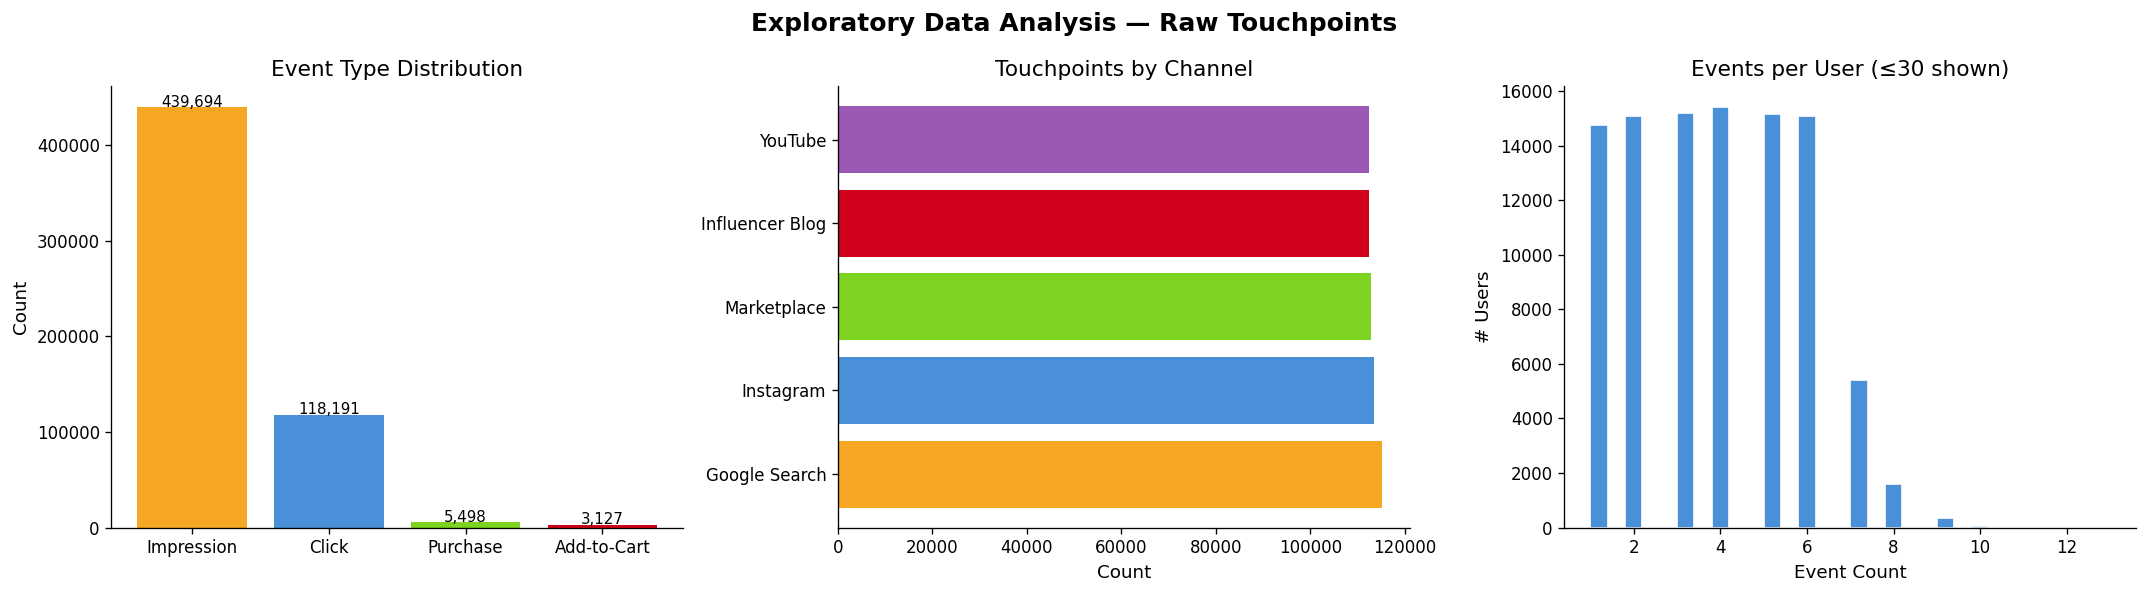

In [6]:
# ═══════════════════════════════════════════════════════════════
# CELL 3 — EDA VISUALISATIONS
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis — Raw Touchpoints', fontsize=15, fontweight='bold')

# 1. Event type distribution
ev_counts = tp_raw['Event_Type'].value_counts()
axes[0].bar(ev_counts.index, ev_counts.values, color=PALETTE[:4])
axes[0].set_title('Event Type Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(ev_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=9)

# 2. Channel mix
ch_counts = tp_raw['Channel'].value_counts()
axes[1].barh(ch_counts.index, ch_counts.values, color=PALETTE[:5])
axes[1].set_title('Touchpoints by Channel')
axes[1].set_xlabel('Count')

# 3. Events per user distribution
epu = tp_raw.groupby('User_ID').size()
axes[2].hist(epu[epu <= 30], bins=30, color=PALETTE[1], edgecolor='white')
axes[2].set_title('Events per User (≤30 shown)')
axes[2].set_xlabel('Event Count')
axes[2].set_ylabel('# Users')

plt.tight_layout()
plt.show()

In [7]:
# ═══════════════════════════════════════════════════════════════
# CELL 4 — BOT TRAFFIC DETECTION (4-Signal Heuristic Model)
# ═══════════════════════════════════════════════════════════════
# Signals:
#  H1: Event count per user > P99 (extreme volume)
#  H2: Click-through-rate per user > 90% (humanly impossible)
#  H3: ≥3 events from same user within the same second
#  H4: ≥5 clicks with no prior impression on same campaign (orphaned clicks)
# A user is flagged as BOT if they trigger ≥ 2 signals.

tp = tp_raw.copy().sort_values(['User_ID', 'Timestamp']).reset_index(drop=True)

# H1 — High event volume
epu  = tp.groupby('User_ID').size()
p99  = epu.quantile(0.99)
h1_bots = set(epu[epu > p99].index)
print(f'H1 (event count > P99={p99:.0f}):  {len(h1_bots):,} users flagged')

# H2 — Impossibly high CTR
clicks_u      = tp[tp['Event_Type']=='Click'].groupby('User_ID').size()
impressions_u = tp[tp['Event_Type']=='Impression'].groupby('User_ID').size()
ctr_u         = (clicks_u / impressions_u).dropna()
h2_bots       = set(ctr_u[ctr_u > 0.9].index)
print(f'H2 (CTR > 90%%):                  {len(h2_bots):,} users flagged')

# H3 — Events within same second
tp['time_diff'] = tp.groupby('User_ID')['Timestamp'].diff().dt.total_seconds()
same_sec = tp[tp['time_diff'] == 0]['User_ID'].value_counts()
h3_bots  = set(same_sec[same_sec >= 3].index)
print(f'H3 (≥3 same-second events):       {len(h3_bots):,} users flagged')

# H4 — Orphaned clicks (click with no prior impression on same campaign)
imp_pairs   = set(zip(tp[tp['Event_Type']=='Impression']['User_ID'],
                       tp[tp['Event_Type']=='Impression']['Campaign_ID']))
click_pairs = set(zip(tp[tp['Event_Type']=='Click']['User_ID'],
                       tp[tp['Event_Type']=='Click']['Campaign_ID']))
orphan_pairs = click_pairs - imp_pairs
orphan_mask  = tp.apply(lambda r: (r['User_ID'], r['Campaign_ID']) in orphan_pairs
                         and r['Event_Type'] == 'Click', axis=1)
orphan_counts = tp[orphan_mask].groupby('User_ID').size()
h4_bots = set(orphan_counts[orphan_counts >= 5].index)
print(f'H4 (≥5 orphaned clicks):          {len(h4_bots):,} users flagged')

# Score & flag bots
user_bot_score = defaultdict(int)
for u in h1_bots: user_bot_score[u] += 1
for u in h2_bots: user_bot_score[u] += 1
for u in h3_bots: user_bot_score[u] += 1
for u in h4_bots: user_bot_score[u] += 1
bot_users = {u for u, s in user_bot_score.items() if s >= 2}

print(f'\n🤖 BOT USERS IDENTIFIED (≥2 signals): {len(bot_users):,}')
print(f'   Bot events: {tp[tp["User_ID"].isin(bot_users)].shape[0]:,}')
print(f'   Bot % of total events: {tp[tp["User_ID"].isin(bot_users)].shape[0]/len(tp)*100:.2f}%')

H1 (event count > P99=98):  960 users flagged
H2 (CTR > 90%%):                  2,935 users flagged
H3 (≥3 same-second events):       1,965 users flagged
H4 (≥5 orphaned clicks):          0 users flagged

🤖 BOT USERS IDENTIFIED (≥2 signals): 1,953
   Bot events: 193,947
   Bot % of total events: 34.24%


Raw events   : 566,510
Clean events : 372,563
Removed      : 193,947 (34.24%)
Clean users  : 98,047

Bot removal by channel:
                 Before  After  Removed %
Channel                                  
Google Search    115239  76369      33.73
Influencer Blog  112417  73884      34.28
Instagram        113529  74419      34.45
Marketplace      112947  74147      34.35
YouTube          112378  73744      34.38


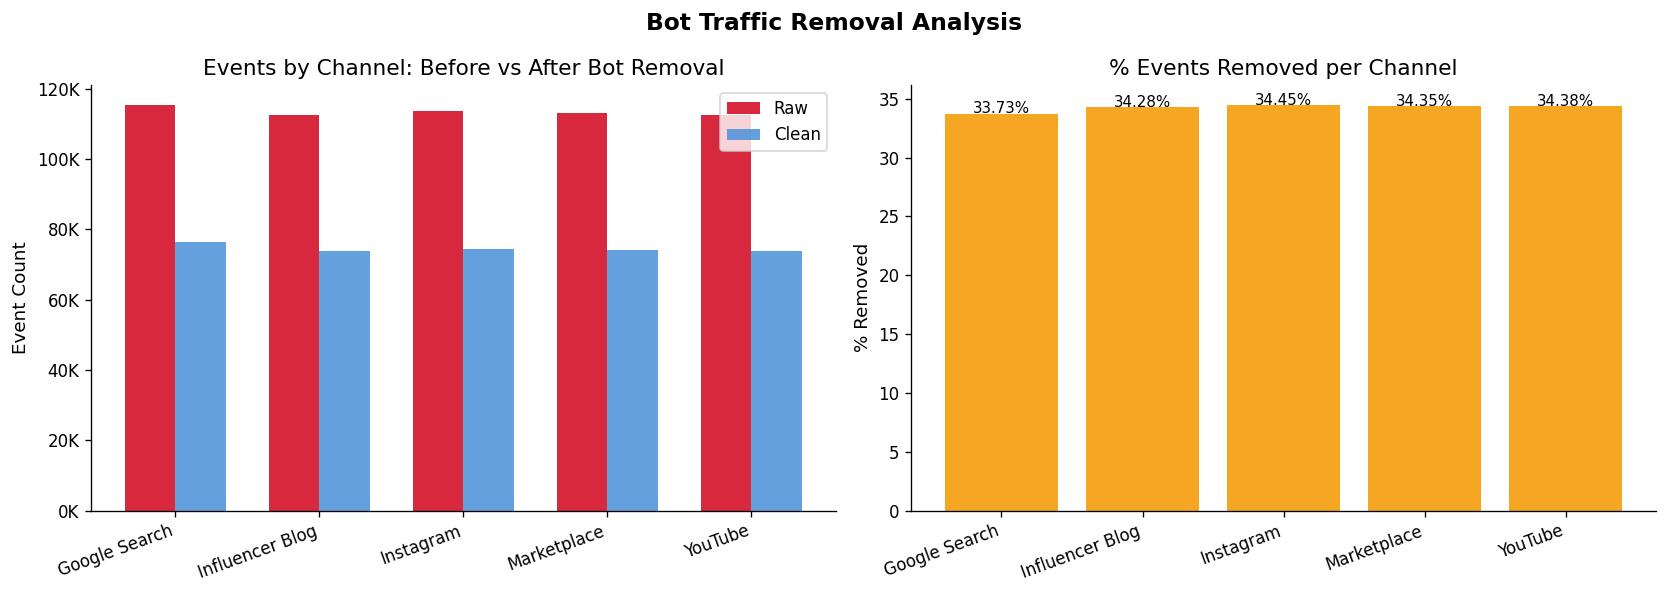

In [8]:
# ═══════════════════════════════════════════════════════════════
# CELL 5 — CLEAN DATA & VISUALISE BOT REMOVAL
# ═══════════════════════════════════════════════════════════════
tp_clean = tp[~tp['User_ID'].isin(bot_users)].copy().drop(columns=['time_diff'])
tp_clean = tp_clean.merge(up_raw[['User_ID','Segment','Geography']], on='User_ID', how='left')

print(f'Raw events   : {len(tp_raw):,}')
print(f'Clean events : {len(tp_clean):,}')
print(f'Removed      : {len(tp_raw)-len(tp_clean):,} ({(len(tp_raw)-len(tp_clean))/len(tp_raw)*100:.2f}%)')
print(f'Clean users  : {tp_clean["User_ID"].nunique():,}')

before = tp_raw.groupby('Channel').size()
after  = tp_clean.groupby('Channel').size()
compare_ch = pd.DataFrame({'Before': before, 'After': after}).fillna(0)
compare_ch['Removed %'] = ((compare_ch['Before'] - compare_ch['After'])/compare_ch['Before']*100).round(2)
print('\nBot removal by channel:')
print(compare_ch.to_string())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bot Traffic Removal Analysis', fontsize=14, fontweight='bold')

x = np.arange(len(compare_ch))
w = 0.35
axes[0].bar(x-w/2, compare_ch['Before'], w, label='Raw', color='#D0021B', alpha=0.85)
axes[0].bar(x+w/2, compare_ch['After'],  w, label='Clean', color='#4A90D9', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(compare_ch.index, rotation=20, ha='right')
axes[0].set_title('Events by Channel: Before vs After Bot Removal')
axes[0].set_ylabel('Event Count')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))

axes[1].bar(compare_ch.index, compare_ch['Removed %'], color=PALETTE[0])
axes[1].set_title('% Events Removed per Channel')
axes[1].set_ylabel('% Removed')
axes[1].set_xticklabels(compare_ch.index, rotation=20, ha='right')
for i, v in enumerate(compare_ch['Removed %']):
    axes[1].text(i, v+0.05, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Computing Last-Click Attribution...
Total LC conversions: 5,498

=== LAST-CLICK CONVERSIONS BY BRAND × CHANNEL ===
Channel   Direct/Unknown  Google Search  Influencer Blog  Instagram  Marketplace  YouTube  Total
Brand_ID                                                                                        
B01                  549             27               33         35           23       31    698
B02                  983             90               71         52           39       42   1277
B03                  246              8               10         15           11       13    303
B04                  244             11               12         21           15       12    315
B05                  134             11                5          5            6        0    161
B06                  240              8               13         15            8        6    290
B07                 1269            128               67         66           53       50   1633
B08         

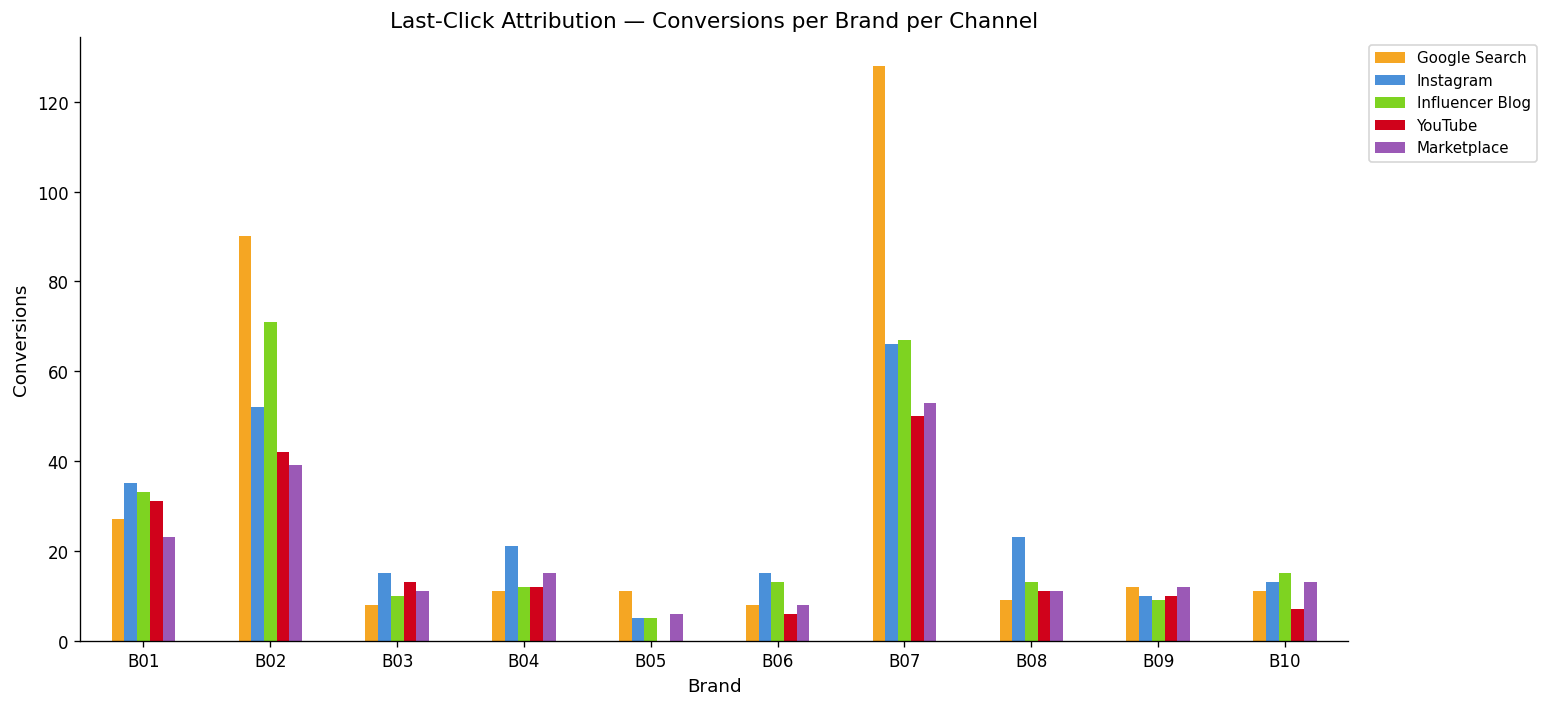

In [9]:
# ═══════════════════════════════════════════════════════════════
# CELL 6 — LAST-CLICK ATTRIBUTION
# ═══════════════════════════════════════════════════════════════
purchases = tp_clean[tp_clean['Event_Type'] == 'Purchase'].copy()
clicks_df = tp_clean[tp_clean['Event_Type'] == 'Click'][['User_ID','Timestamp','Channel','Brand_ID']].copy()
clicks_df = clicks_df.sort_values(['User_ID','Timestamp'])

def last_click_attribution(purchases_df, clicks_df):
    """Assign each purchase to the channel of the last click before it."""
    results = []
    for _, row in purchases_df.iterrows():
        uid   = row['User_ID']
        ts    = row['Timestamp']
        brand = row['Brand_ID']
        prev  = clicks_df[(clicks_df['User_ID']==uid) & (clicks_df['Timestamp']<ts)]
        if not prev.empty:
            last = prev.iloc[-1]
            results.append({'Brand_ID': brand, 'Channel': last['Channel'], 'Conversions': 1})
        else:
            results.append({'Brand_ID': brand, 'Channel': 'Direct/Unknown', 'Conversions': 1})
    return pd.DataFrame(results).groupby(['Brand_ID','Channel'])['Conversions'].sum().reset_index()

print('Computing Last-Click Attribution...')
lc_attr  = last_click_attribution(purchases, clicks_df)
lc_pivot = lc_attr.pivot_table(index='Brand_ID', columns='Channel',
                                values='Conversions', aggfunc='sum', fill_value=0)
lc_pivot['Total'] = lc_pivot.sum(axis=1)

print(f'Total LC conversions: {lc_attr["Conversions"].sum():,}')
print('\n=== LAST-CLICK CONVERSIONS BY BRAND × CHANNEL ===')
print(lc_pivot.to_string())

# Visualise
fig, ax = plt.subplots(figsize=(13, 6))
lc_plot = lc_pivot.drop(columns='Total')
lc_plot_filtered = lc_plot[[c for c in CHANNELS if c in lc_plot.columns]]
lc_plot_filtered.plot(kind='bar', ax=ax, color=PALETTE[:5])
ax.set_title('Last-Click Attribution — Conversions per Brand per Channel')
ax.set_ylabel('Conversions')
ax.set_xlabel('Brand')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Building consumer journey paths (this takes ~15s)...
Total journeys     : 19,203
Converting         : 1,191
Non-converting     : 18,012
Journey conv rate  : 6.20%


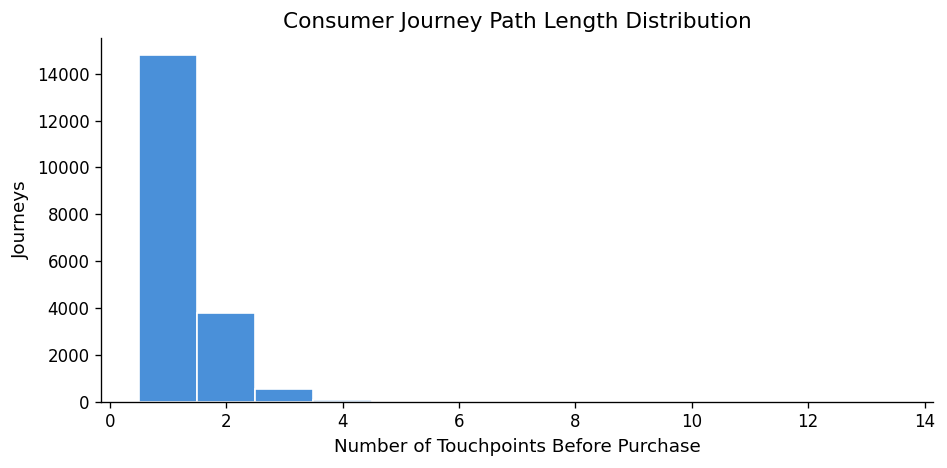

In [10]:
# ═══════════════════════════════════════════════════════════════
# CELL 7 — BUILD CONSUMER JOURNEY PATHS
# ═══════════════════════════════════════════════════════════════
def build_journeys(tp_df):
    """
    Build ordered channel sequences per user×brand.
    Uses Click + Add-to-Cart as meaningful pre-conversion touchpoints.
    Returns list of {user_id, brand_id, path, converted}.
    """
    journeys = []
    meaningful = tp_df[tp_df['Event_Type'].isin(['Click','Add-to-Cart','Purchase'])].copy()
    meaningful = meaningful.sort_values(['User_ID','Timestamp'])
    for (uid, brand), grp in meaningful.groupby(['User_ID','Brand_ID']):
        path = []
        converted = False
        for _, row in grp.iterrows():
            if row['Event_Type'] == 'Purchase':
                converted = True
                break
            path.append(row['Channel'])
        if path:
            journeys.append({'user_id': uid, 'brand_id': brand,
                             'path': path, 'converted': converted})
    return journeys

print('Building consumer journey paths (this takes ~15s)...')
journeys      = build_journeys(tp_clean)
converting    = [j for j in journeys if j['converted']]
non_converting = [j for j in journeys if not j['converted']]

print(f'Total journeys     : {len(journeys):,}')
print(f'Converting         : {len(converting):,}')
print(f'Non-converting     : {len(non_converting):,}')
print(f'Journey conv rate  : {len(converting)/len(journeys)*100:.2f}%')

# Path length distribution
path_lengths = [len(j['path']) for j in journeys]
fig, ax = plt.subplots(figsize=(8,4))
ax.hist(path_lengths, bins=range(1,15), color=PALETTE[1], edgecolor='white', align='left')
ax.set_title('Consumer Journey Path Length Distribution')
ax.set_xlabel('Number of Touchpoints Before Purchase')
ax.set_ylabel('Journeys')
plt.tight_layout()
plt.show()

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 — MARKOV CHAIN ATTRIBUTION (Removal Effect)
# ═══════════════════════════════════════════════════════════════
def build_transition_matrix(journeys_list, channels):
    """Build stochastic transition matrix for Markov chain with absorbing states."""
    states = ['Start'] + channels + ['Conversion', 'Null']
    trans_counts = defaultdict(lambda: defaultdict(int))
    for j in journeys_list:
        full = ['Start'] + j['path'] + (['Conversion'] if j['converted'] else ['Null'])
        for i in range(len(full)-1):
            trans_counts[full[i]][full[i+1]] += 1
    trans_prob = {}
    for state in states:
        total = sum(trans_counts[state].values())
        trans_prob[state] = ({s: trans_counts[state][s]/total
                              for s in trans_counts[state]} if total > 0 else {})
    trans_prob['Conversion'] = {'Conversion': 1.0}
    trans_prob['Null']       = {'Null': 1.0}
    return trans_prob, states

def conversion_probability(trans_prob, states, max_steps=50):
    """Compute probability of reaching Conversion from Start via matrix power."""
    state_idx = {s: i for i, s in enumerate(states)}
    n = len(states)
    T = np.zeros((n, n))
    for s, nexts in trans_prob.items():
        if s in state_idx:
            for ns, p in nexts.items():
                if ns in state_idx:
                    T[state_idx[s], state_idx[ns]] = p
    v = np.zeros(n)
    v[state_idx['Start']] = 1.0
    for _ in range(max_steps):
        v = v @ T
    return v[state_idx['Conversion']]

def markov_removal_effect(journeys_list, channels):
    """Compute Markov removal effect: how much does removing each channel hurt conv rate?"""
    trans_prob, states = build_transition_matrix(journeys_list, channels)
    baseline = conversion_probability(trans_prob, states)
    effects  = {}
    for ch in channels:
        tp_mod = defaultdict(dict)
        for s, nexts in trans_prob.items():
            for ns, p in nexts.items():
                if ns == ch:          # redirect into channel → Null
                    tp_mod[s]['Null'] = tp_mod[s].get('Null', 0) + p
                elif s != ch:         # keep all other transitions
                    tp_mod[s][ns]     = tp_mod[s].get(ns, 0) + p
        tp_mod['Conversion'] = {'Conversion': 1.0}
        tp_mod['Null']       = {'Null': 1.0}
        if ch not in tp_mod:
            tp_mod[ch] = {'Null': 1.0}
        effects[ch] = max(0, baseline - conversion_probability(dict(tp_mod), states))
    total = sum(effects.values())
    return ({ch: v/total for ch, v in effects.items()} if total > 0 else effects), baseline

print('Computing Markov Chain attribution per brand...')
markov_results = {}
for brand in BRANDS:
    bj     = [j for j in journeys if j['brand_id'] == brand]
    n_conv = sum(1 for j in bj if j['converted'])
    if len(bj) < 10:
        markov_results[brand] = {ch: 0 for ch in CHANNELS}
        continue
    re, _ = markov_removal_effect(bj, CHANNELS)
    markov_results[brand] = {ch: re.get(ch, 0) * n_conv for ch in CHANNELS}

markov_df = pd.DataFrame(markov_results).T
markov_df.index.name = 'Brand_ID'
markov_df['Total_Conversions'] = markov_df[CHANNELS].sum(axis=1)
print('\n=== MARKOV CHAIN ATTRIBUTED CONVERSIONS ===')
print(markov_df.round(1).to_string())

Computing Markov Chain attribution per brand...

=== MARKOV CHAIN ATTRIBUTED CONVERSIONS ===
          Google Search  Instagram  Influencer Blog  YouTube  Marketplace  Total_Conversions
Brand_ID                                                                                    
B01                27.5       34.2             32.8     31.1         23.4              149.0
B02                86.1       52.9             69.8     45.4         39.9              294.0
B03                 8.2       14.6             10.0     12.9         11.3               57.0
B04                11.3       20.3             12.2     12.5         14.7               71.0
B05                10.6        4.9              5.1      0.6          5.8               27.0
B06                 8.3       14.4             12.6      6.4          8.3               50.0
B07               121.7       66.1             67.3     53.3         55.7              364.0
B08                 9.3       21.9             13.1     11.6         1

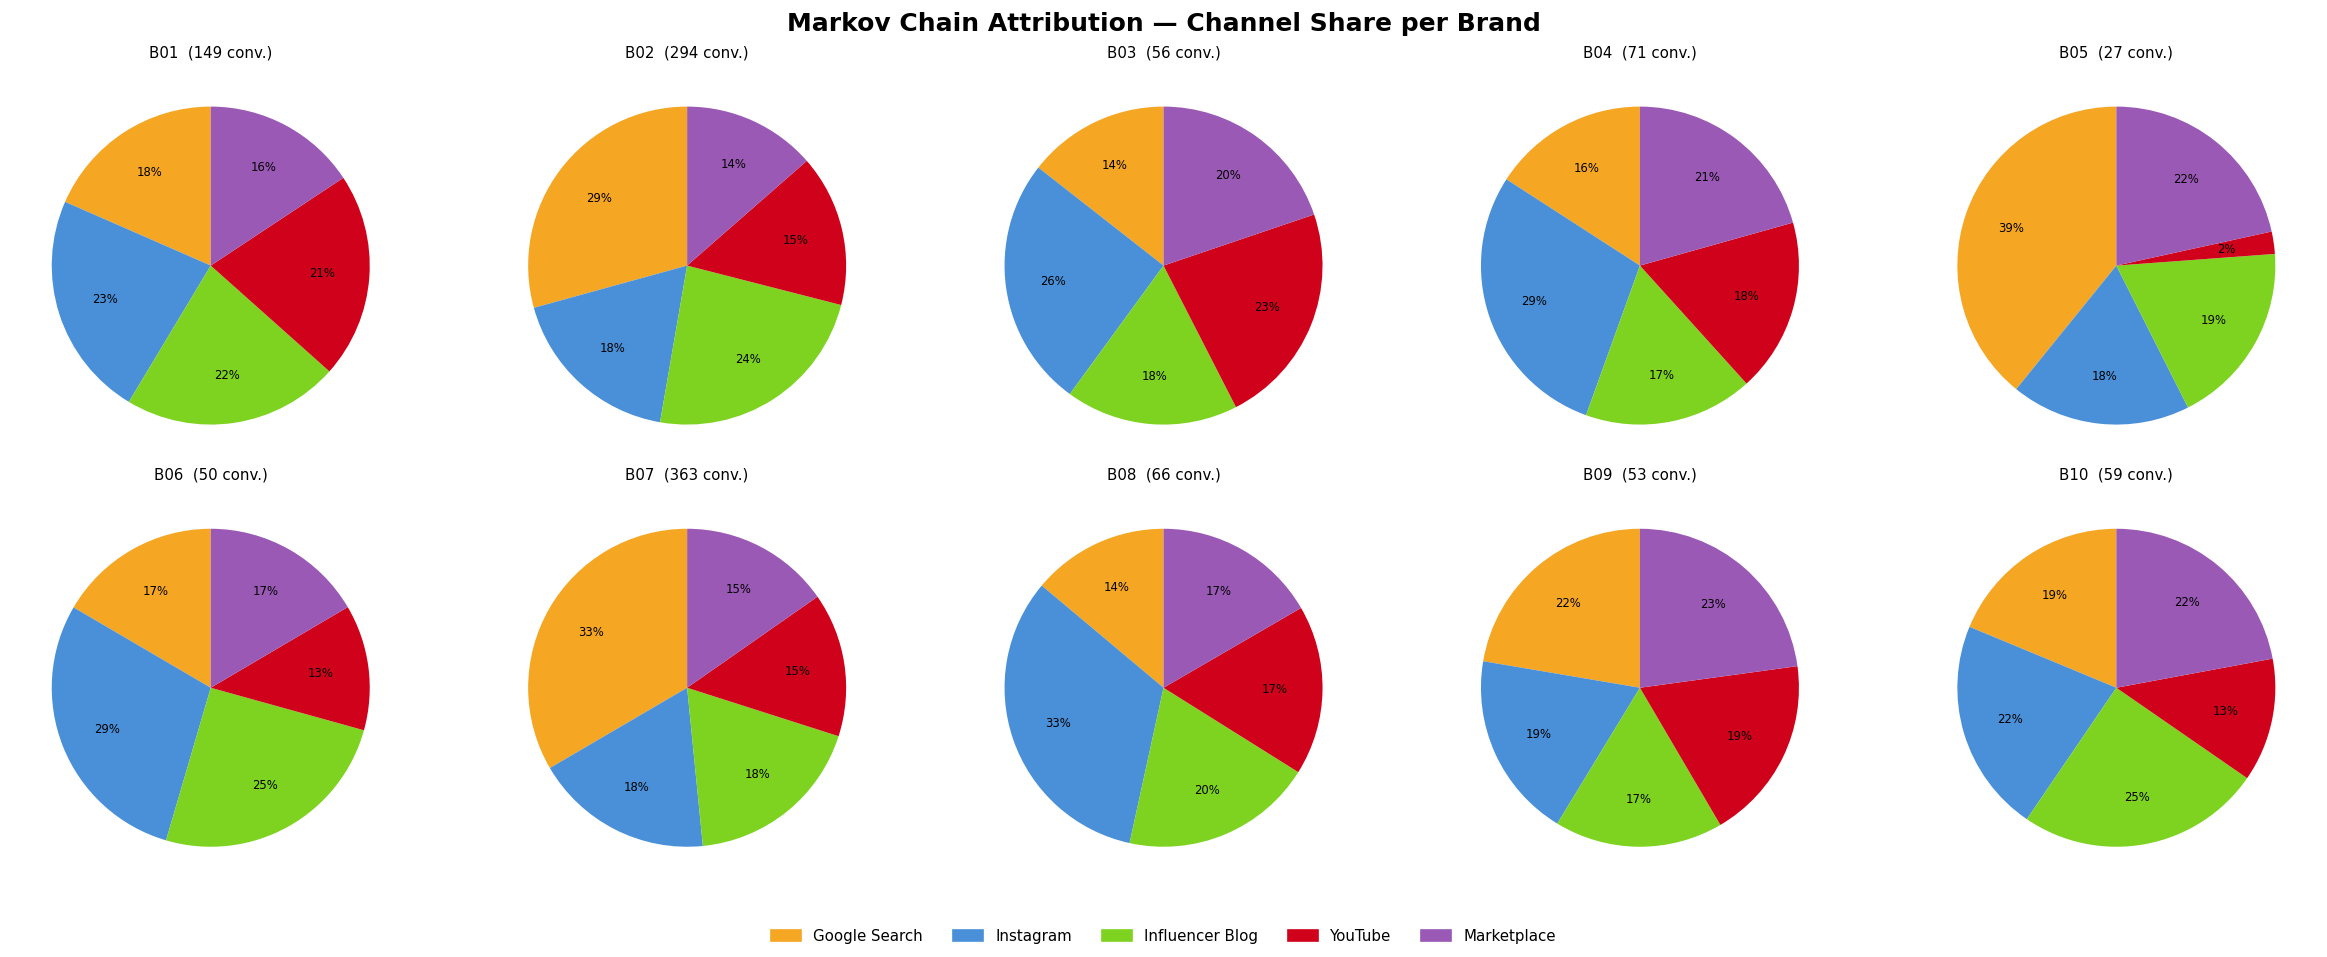

In [12]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 — MARKOV ATTRIBUTION VISUALISATION
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Markov Chain Attribution — Channel Share per Brand', fontsize=15, fontweight='bold')

for idx, brand in enumerate(BRANDS):
    ax = axes[idx // 5][idx % 5]
    vals = markov_df.loc[brand, CHANNELS].astype(float)
    total = vals.sum()
    if total > 0:
        ax.pie(vals, labels=None, autopct='%1.0f%%',
               colors=PALETTE[:len(CHANNELS)], startangle=90,
               pctdistance=0.7, textprops={'fontsize': 7})
    ax.set_title(f'{brand}  ({int(total)} conv.)', fontsize=9)

handles = [plt.Rectangle((0,0),1,1, color=PALETTE[i]) for i in range(len(CHANNELS))]
fig.legend(handles, CHANNELS, loc='lower center', ncol=5, fontsize=9, frameon=False)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [13]:
# ═══════════════════════════════════════════════════════════════
# CELL 10 — SHAPLEY VALUE ATTRIBUTION
# ═══════════════════════════════════════════════════════════════
# Shapley value: assign credit based on marginal contribution
# across all possible ordered coalitions of channels.
# v(S) = conversion rate of paths that contain all channels in S.

def compute_shapley(journeys_list, channels):
    """Compute Shapley values via characteristic function on journey sets."""
    if not journeys_list:
        return {ch: 0.0 for ch in channels}
    n = len(channels)
    j_all  = [set(j['path']) for j in journeys_list]
    j_conv = [set(j['path']) for j in journeys_list if j['converted']]

    def v(S):
        S_set = set(S)
        with_S = [p for p in j_all if S_set.issubset(p)]
        conv_S = [p for p in j_conv if S_set.issubset(p)]
        return len(conv_S)/len(with_S) if with_S else 0

    shapley_vals = {ch: 0.0 for ch in channels}
    n_fact = math.factorial(n)
    for ch in channels:
        others = [c for c in channels if c != ch]
        for perm in permutations(others):
            for pos in range(len(perm)+1):
                S_w  = list(perm[:pos])
                S_wo = list(perm[:pos]) + [ch]
                shapley_vals[ch] += v(S_wo) - v(S_w)
        shapley_vals[ch] /= (n_fact * n)

    shapley_vals = {ch: max(0, v) for ch, v in shapley_vals.items()}
    total = sum(shapley_vals.values())
    return ({ch: v/total for ch, v in shapley_vals.items()}
            if total > 0 else shapley_vals)

print('Computing Shapley Value attribution per brand (may take ~60s)...')
shapley_results = {}
for brand in BRANDS:
    bj     = [j for j in journeys if j['brand_id'] == brand]
    n_conv = sum(1 for j in bj if j['converted'])
    sw     = compute_shapley(bj, CHANNELS)
    shapley_results[brand] = {ch: sw.get(ch, 0) * n_conv for ch in CHANNELS}

shapley_df = pd.DataFrame(shapley_results).T
shapley_df.index.name = 'Brand_ID'
shapley_df['Total_Conversions'] = shapley_df[CHANNELS].sum(axis=1)
print('\n=== SHAPLEY VALUE ATTRIBUTED CONVERSIONS ===')
print(shapley_df.round(1).to_string())

Computing Shapley Value attribution per brand (may take ~60s)...

=== SHAPLEY VALUE ATTRIBUTED CONVERSIONS ===
          Google Search  Instagram  Influencer Blog  YouTube  Marketplace  Total_Conversions
Brand_ID                                                                                    
B01                 0.0        0.0              0.0    149.0          0.0              149.0
B02               294.0        0.0              0.0      0.0          0.0              294.0
B03                 0.0        0.0              0.0      0.0          0.0                0.0
B04                21.2       20.9              0.0      0.0         28.9               71.0
B05                27.0        0.0              0.0      0.0          0.0               27.0
B06                 0.0        0.0              0.0     50.0          0.0               50.0
B07               171.8       66.1              0.0    126.1          0.0              364.0
B08                 0.0       67.0              0.0 

=== ENSEMBLE MULTI-TOUCH ATTRIBUTED CONVERSIONS ===
     Google Search  Instagram  Influencer Blog  YouTube  Marketplace  Total_Attributed
B01           13.7       17.1             16.4     90.1         11.7             149.0
B02          190.0       26.4             34.9     22.7         19.9             294.0
B03            4.1        7.3              5.0      6.5          5.6              28.5
B04           16.2       20.6              6.1      6.3         21.8              71.0
B05           18.8        2.5              2.5      0.3          2.9              27.0
B06            4.1        7.2              6.3     28.2          4.1              50.0
B07          146.7       66.1             33.7     89.7         27.8             364.0
B08            4.7       44.4              6.5      5.8          5.6              67.0
B09            5.9        5.0              4.5      5.0          6.0              26.5
B10            5.5        6.4              7.3      3.7          6.5          

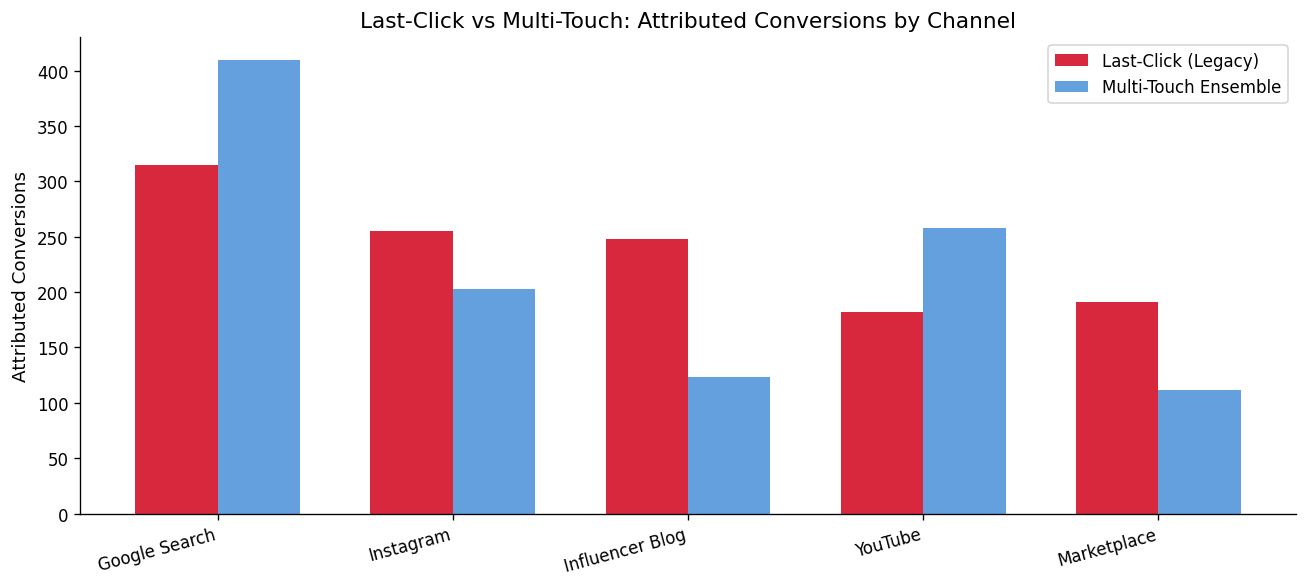

In [14]:
# ═══════════════════════════════════════════════════════════════
# CELL 11 — ENSEMBLE ATTRIBUTION & MODEL COMPARISON
# ═══════════════════════════════════════════════════════════════
# Ensemble = average of Markov + Shapley (robust to individual model biases)
ensemble_df = pd.DataFrame(index=BRANDS, columns=CHANNELS, dtype=float)
for brand in BRANDS:
    for ch in CHANNELS:
        ensemble_df.loc[brand, ch] = (
            float(markov_df.loc[brand, ch]) + float(shapley_df.loc[brand, ch])
        ) / 2
ensemble_df = ensemble_df.astype(float)
ensemble_df['Total_Attributed'] = ensemble_df[CHANNELS].sum(axis=1)

print('=== ENSEMBLE MULTI-TOUCH ATTRIBUTED CONVERSIONS ===')
print(ensemble_df.round(1).to_string())

# Attribution model comparison: Last-Click vs Multi-Touch
lc_ch_total = (lc_attr[lc_attr['Channel'].isin(CHANNELS)]
               .groupby('Channel')['Conversions'].sum()
               .reindex(CHANNELS, fill_value=0))
mt_ch_total = ensemble_df[CHANNELS].sum().reindex(CHANNELS, fill_value=0)

comp_model = pd.DataFrame({
    'Last-Click Conversions': lc_ch_total.round(0).astype(int),
    'Multi-Touch Conversions': mt_ch_total.round(0).astype(int),
    'Delta (MT - LC)': (mt_ch_total - lc_ch_total).round(0).astype(int),
    'Delta %': ((mt_ch_total - lc_ch_total) /
                lc_ch_total.replace(0, np.nan) * 100).round(1)
})
print('\n=== ATTRIBUTION MODEL COMPARISON BY CHANNEL ===')
print(comp_model.to_string())
print('\n  Positive Delta = Under-credited by Last-Click')
print('  Negative Delta = Over-credited by Last-Click')

# Visualise
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(CHANNELS))
w = 0.35
ax.bar(x-w/2, comp_model['Last-Click Conversions'], w, label='Last-Click (Legacy)', color='#D0021B', alpha=0.85)
ax.bar(x+w/2, comp_model['Multi-Touch Conversions'], w, label='Multi-Touch Ensemble', color='#4A90D9', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CHANNELS, rotation=15, ha='right')
ax.set_title('Last-Click vs Multi-Touch: Attributed Conversions by Channel')
ax.set_ylabel('Attributed Conversions')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# ═══════════════════════════════════════════════════════════════
# CELL 12 — SPEND, CPA, ROI COMPUTATION
# ═══════════════════════════════════════════════════════════════
# Spend source: Total_Budget_Allocated from campaign_spend.csv
# (This represents the actual capital deployed per campaign in the quarter.)

spend_by_brand_channel = (
    cs_raw.groupby(['Brand_ID', 'Channel'])['Total_Budget_Allocated']
    .sum()
    .unstack(fill_value=0)
)
spend_by_brand = cs_raw.groupby('Brand_ID')['Total_Budget_Allocated'].sum()

print('=== ACTUAL SPEND BY BRAND × CHANNEL (₹ Crore) ===')
print((spend_by_brand_channel / 1e7).round(2).to_string())

print('\nTotal Spend by Brand:')
for b, s in spend_by_brand.items():
    print(f'  {b}: ₹{s/1e7:.2f} Crore')
print(f'\n  TOTAL: ₹{spend_by_brand.sum()/1e7:.2f} Crore')

# CPA per brand × channel
cpa_df = pd.DataFrame(index=BRANDS, columns=CHANNELS, dtype=float)
for brand in BRANDS:
    for ch in CHANNELS:
        spend = spend_by_brand_channel.loc[brand, ch] if ch in spend_by_brand_channel.columns else 0
        conv  = float(ensemble_df.loc[brand, ch])
        cpa_df.loc[brand, ch] = round(spend / conv, 2) if conv > 0.01 else np.nan
cpa_df = cpa_df.astype(float)

# Brand-level summary
brand_summary = pd.DataFrame(index=BRANDS)
brand_summary['Spend_Cr']    = spend_by_brand / 1e7
brand_summary['Conv']        = ensemble_df['Total_Attributed']
brand_summary['CPA_INR']     = (spend_by_brand / ensemble_df['Total_Attributed']).replace([np.inf], np.nan)
brand_summary['Revenue_Cr']  = ensemble_df['Total_Attributed'] * AOV_INR / 1e7
brand_summary['ROI_%']       = ((brand_summary['Revenue_Cr'] - brand_summary['Spend_Cr'])
                                / brand_summary['Spend_Cr'] * 100).round(1)

print('\n=== BRAND-LEVEL FINANCIAL SUMMARY (AOV assumed = ₹800) ===')
print(brand_summary.round(2).to_string())

print('\n=== CPA BY BRAND × CHANNEL (₹) ===')
print(cpa_df.round(0).to_string())

=== ACTUAL SPEND BY BRAND × CHANNEL (₹ Crore) ===
Channel   Google Search  Influencer Blog  Instagram  Marketplace  YouTube
Brand_ID                                                                 
B01                2.79             1.45       0.06         3.72     1.98
B02                2.37             0.16       2.11         3.12     2.25
B03                0.76             0.77       1.43         2.12     4.92
B04                3.65             3.04       1.53         0.36     1.42
B05                1.57             1.82       4.05         0.42     4.00
B06                3.94             0.66       0.07         2.18     3.14
B07                2.63             0.31       4.81         2.02     0.23
B08                0.29             0.33       0.90         4.23     4.25
B09                0.45             2.76       0.47         4.73     1.59
B10                1.85             0.20       3.98         1.16     2.82

Total Spend by Brand:
  B01: ₹10.00 Crore
  B02: ₹10.00 Crore

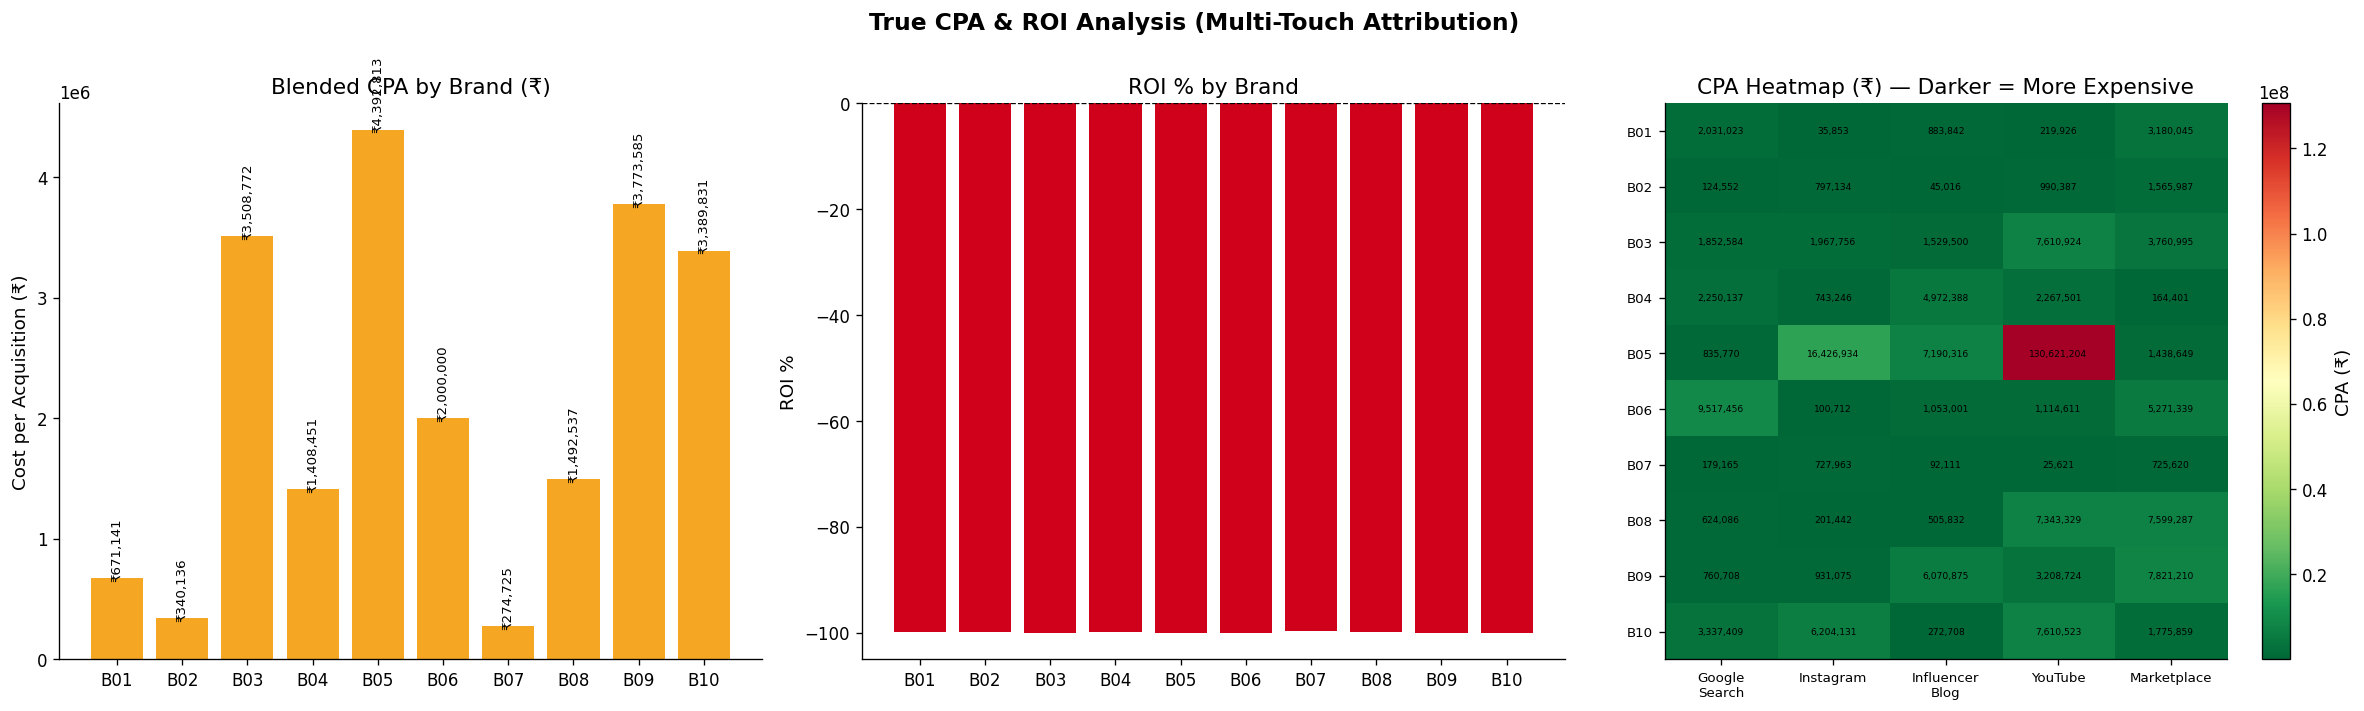

In [16]:
# ═══════════════════════════════════════════════════════════════
# CELL 13 — CPA / ROI VISUALISATIONS
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('True CPA & ROI Analysis (Multi-Touch Attribution)', fontsize=14, fontweight='bold')

# 1. Blended CPA by brand
cpa_vals = brand_summary['CPA_INR'].fillna(0)
axes[0].bar(BRANDS, cpa_vals, color=PALETTE[0])
axes[0].set_title('Blended CPA by Brand (₹)')
axes[0].set_ylabel('Cost per Acquisition (₹)')
for i, v in enumerate(cpa_vals):
    axes[0].text(i, v+30, f'₹{v:,.0f}', ha='center', fontsize=8, rotation=90)

# 2. ROI by brand
roi_vals = brand_summary['ROI_%'].fillna(0)
bar_colors = ['#7ED321' if v > 0 else '#D0021B' for v in roi_vals]
axes[1].bar(BRANDS, roi_vals, color=bar_colors)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('ROI % by Brand')
axes[1].set_ylabel('ROI %')

# 3. CPA Heatmap
cpa_fill = cpa_df.copy().fillna(cpa_df.max().max() * 1.5)
im = axes[2].imshow(cpa_fill.values, aspect='auto', cmap='RdYlGn_r')
axes[2].set_xticks(range(len(CHANNELS)))
axes[2].set_xticklabels([c.replace(' ','\n') for c in CHANNELS], fontsize=8)
axes[2].set_yticks(range(len(BRANDS)))
axes[2].set_yticklabels(BRANDS, fontsize=8)
axes[2].set_title('CPA Heatmap (₹) — Darker = More Expensive')
plt.colorbar(im, ax=axes[2], label='CPA (₹)')
for i in range(len(BRANDS)):
    for j in range(len(CHANNELS)):
        val = cpa_df.iloc[i, j]
        if not np.isnan(val):
            axes[2].text(j, i, f'{int(val):,}', ha='center', va='center',
                         fontsize=5.5, color='black')
plt.tight_layout()
plt.show()

=== CHANNEL FUNNEL POSITION ANALYSIS ===
                 First-Touch  Last-Touch  Assist  Avg_Position_Norm
Google Search            317         315      18               0.19
Instagram                251         255       9               0.23
Influencer Blog          250         248       8               0.20
YouTube                  184         182      19               0.22
Marketplace              189         191      14               0.22

  Avg_Position_Norm → 0: Top-of-Funnel PRIMER
  Avg_Position_Norm → 1: Conversion CLOSER


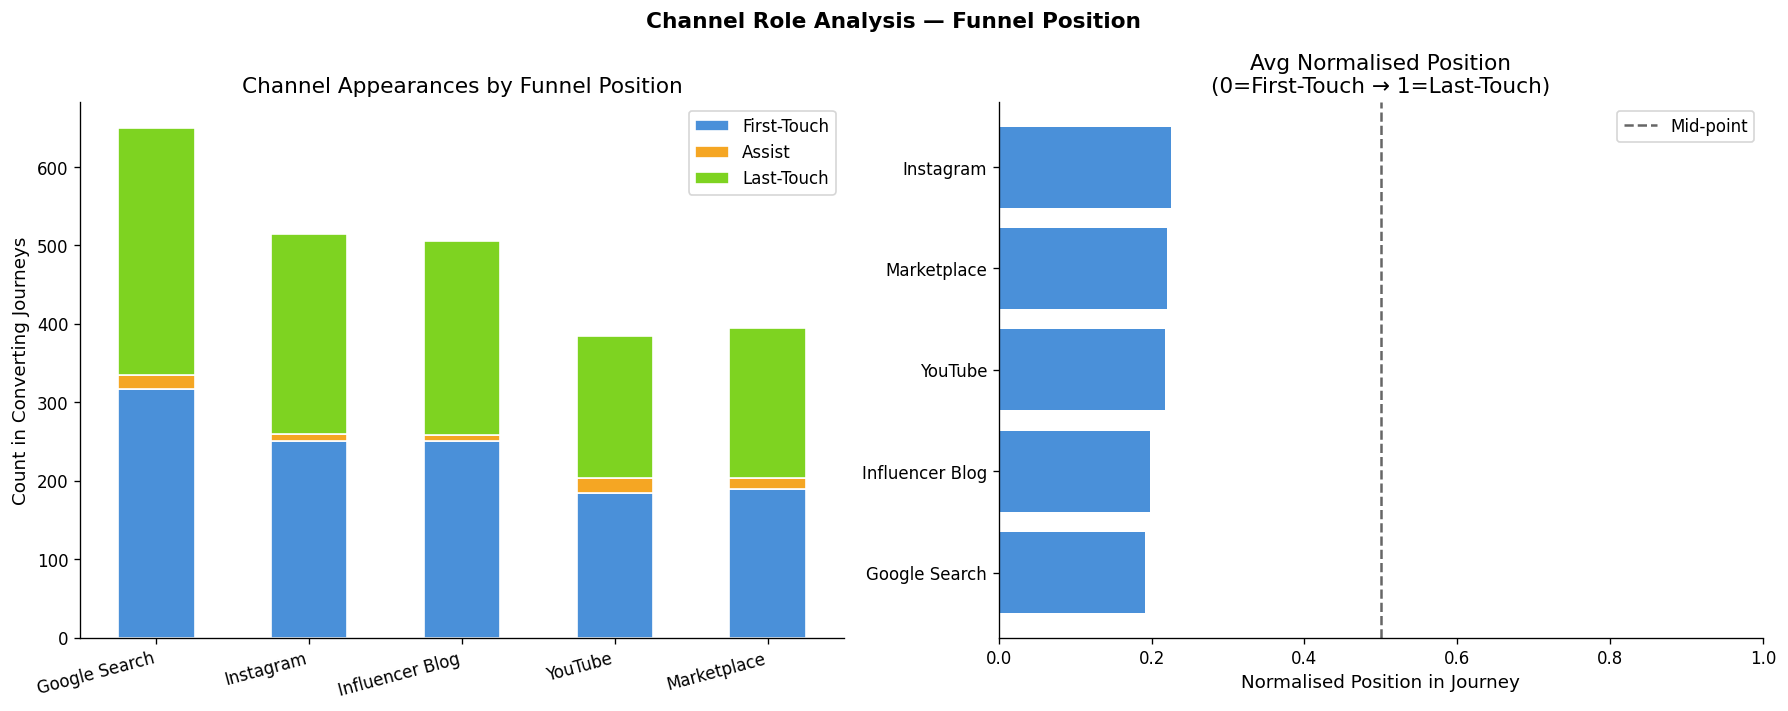

In [17]:
# ═══════════════════════════════════════════════════════════════
# CELL 14 — CHANNEL FUNNEL POSITION ANALYSIS
# ═══════════════════════════════════════════════════════════════
position_counts    = defaultdict(lambda: defaultdict(int))
channel_positions  = defaultdict(list)

for j in converting:
    path = j['path']
    if not path: continue
    n = len(path)
    position_counts[path[0]]['First-Touch']  += 1
    position_counts[path[-1]]['Last-Touch']  += 1
    for ch in path[1:-1]:
        position_counts[ch]['Assist'] += 1
    for pos, ch in enumerate(path):
        channel_positions[ch].append(pos / max(n-1, 1))

position_df = pd.DataFrame(position_counts).T.fillna(0).reindex(CHANNELS, fill_value=0)
position_df['Avg_Position_Norm'] = pd.Series({ch: np.mean(v)
                                              for ch, v in channel_positions.items()})
position_df['Avg_Position_Norm'] = position_df['Avg_Position_Norm'].fillna(0.5)

print('=== CHANNEL FUNNEL POSITION ANALYSIS ===')
print(position_df.round(2).to_string())
print('\n  Avg_Position_Norm → 0: Top-of-Funnel PRIMER')
print('  Avg_Position_Norm → 1: Conversion CLOSER')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Channel Role Analysis — Funnel Position', fontsize=13, fontweight='bold')

pos_plot = position_df[['First-Touch','Assist','Last-Touch']]
pos_plot.plot(kind='bar', stacked=True, ax=axes[0],
              color=['#4A90D9','#F5A623','#7ED321'], edgecolor='white')
axes[0].set_title('Channel Appearances by Funnel Position')
axes[0].set_ylabel('Count in Converting Journeys')
axes[0].set_xticklabels(CHANNELS, rotation=15, ha='right')

avp = position_df['Avg_Position_Norm'].sort_values()
bar_c = ['#4A90D9' if v < 0.45 else '#D0021B' if v > 0.55 else '#F5A623' for v in avp]
axes[1].barh(avp.index, avp.values, color=bar_c)
axes[1].axvline(0.5, color='black', linestyle='--', alpha=0.6, label='Mid-point')
axes[1].set_title('Avg Normalised Position\n(0=First-Touch → 1=Last-Touch)')
axes[1].set_xlabel('Normalised Position in Journey')
axes[1].set_xlim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# ═══════════════════════════════════════════════════════════════
# CELL 15 — PER-BRAND CHANNEL ROLE TABLE
# ═══════════════════════════════════════════════════════════════
brand_roles = []
for brand in BRANDS:
    bj = [j for j in converting if j['brand_id'] == brand]
    if not bj: continue
    first_c = defaultdict(int)
    last_c  = defaultdict(int)
    for j in bj:
        p = j['path']
        if p:
            first_c[p[0]]  += 1
            last_c[p[-1]]  += 1
    n = len(bj)
    top_primer = max(first_c, key=first_c.get, default='N/A')
    top_closer = max(last_c,  key=last_c.get,  default='N/A')
    brand_roles.append({
        'Brand': brand,
        'Conversions': n,
        'Top TOF Primer': f"{top_primer} ({first_c.get(top_primer,0)}, {first_c.get(top_primer,0)/n*100:.0f}%)",
        'Top Conversion Driver': f"{top_closer} ({last_c.get(top_closer,0)}, {last_c.get(top_closer,0)/n*100:.0f}%)",
    })

roles_df = pd.DataFrame(brand_roles).set_index('Brand')
print('=== PER-BRAND: TOP-OF-FUNNEL PRIMER vs CONVERSION DRIVER ===')
print(roles_df.to_string())

=== PER-BRAND: TOP-OF-FUNNEL PRIMER vs CONVERSION DRIVER ===
       Conversions             Top TOF Primer      Top Conversion Driver
Brand                                                                   
B01            149  Influencer Blog (33, 22%)        Instagram (35, 23%)
B02            294    Google Search (93, 32%)    Google Search (90, 31%)
B03             57        Instagram (16, 28%)        Instagram (15, 26%)
B04             71        Instagram (22, 31%)        Instagram (21, 30%)
B05             27    Google Search (11, 41%)    Google Search (11, 41%)
B06             50        Instagram (14, 28%)        Instagram (15, 30%)
B07            364   Google Search (125, 34%)   Google Search (128, 35%)
B08             67        Instagram (21, 31%)        Instagram (23, 34%)
B09             53      Marketplace (13, 25%)      Marketplace (12, 23%)
B10             59  Influencer Blog (15, 25%)  Influencer Blog (15, 25%)


=== AD FATIGUE PENALTY FACTOR PER CHANNEL ===
(1.0 = no fatigue; < 0.5 = severe fatigue — apply frequency caps)
  Google Search          0.928  ██████████████████░░  HEALTHY
  Instagram              0.836  ████████████████░░░░  HEALTHY
  Influencer Blog        0.100  ██░░░░░░░░░░░░░░░░░░  APPLY FREQ CAP
  YouTube                0.100  ██░░░░░░░░░░░░░░░░░░  APPLY FREQ CAP
  Marketplace            0.910  ██████████████████░░  HEALTHY


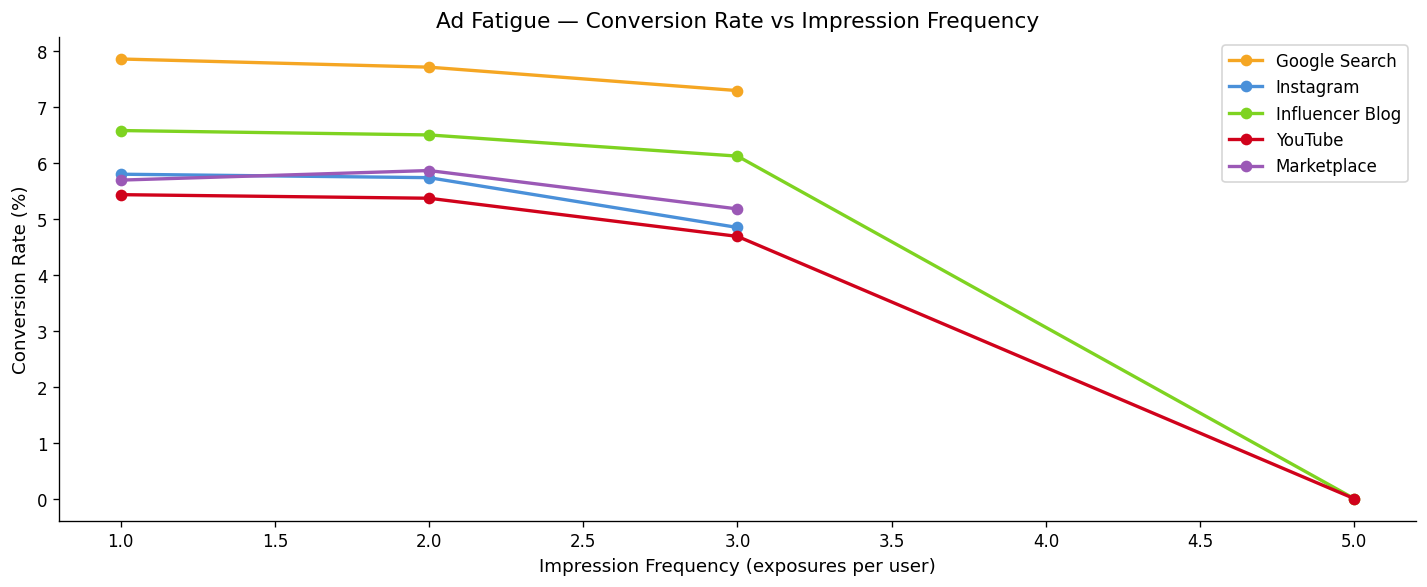

In [19]:
# ═══════════════════════════════════════════════════════════════
# CELL 16 — AD FATIGUE ANALYSIS
# ═══════════════════════════════════════════════════════════════
# Method: Compute conversion rate as a function of impression
# frequency per user. Declining conv rate at higher frequency = fatigue.

fatigue_rows = []
for brand in BRANDS:
    for ch in CHANNELS:
        b_ch = tp_clean[(tp_clean['Brand_ID']==brand) & (tp_clean['Channel']==ch)]
        imp_freq = b_ch[b_ch['Event_Type']=='Impression'].groupby('User_ID').size()
        converters = set(
            tp_clean[(tp_clean['Brand_ID']==brand) &
                     (tp_clean['Event_Type']=='Purchase')]['User_ID']
        )
        for bucket in [1, 2, 3, 5, 8, 10, 15]:
            users = imp_freq[(imp_freq >= bucket) & (imp_freq < bucket*1.6+2)].index
            if len(users) < 5: continue
            cr = len(set(users) & converters) / len(users)
            fatigue_rows.append({'Brand_ID': brand, 'Channel': ch,
                                  'Freq_Bucket': bucket, 'n_users': len(users), 'Conv_Rate': cr})

fatigue_df  = pd.DataFrame(fatigue_rows)
fatigue_agg = fatigue_df.groupby(['Channel','Freq_Bucket'])['Conv_Rate'].mean().reset_index()

# Compute fatigue penalty per channel
fatigue_penalty = {}
for ch in CHANNELS:
    sub = fatigue_agg[fatigue_agg['Channel']==ch].sort_values('Freq_Bucket')
    if len(sub) >= 2:
        max_r = sub['Conv_Rate'].iloc[0]
        min_r = sub['Conv_Rate'].iloc[-1]
        fatigue_penalty[ch] = round(max(0.1, min_r/max_r) if max_r > 0 else 1.0, 3)
    else:
        fatigue_penalty[ch] = 1.0

print('=== AD FATIGUE PENALTY FACTOR PER CHANNEL ===')
print('(1.0 = no fatigue; < 0.5 = severe fatigue — apply frequency caps)')
for ch, p in fatigue_penalty.items():
    bar = '█' * int(p * 20) + '░' * (20 - int(p*20))
    label = 'APPLY FREQ CAP' if p < 0.5 else 'MODERATE' if p < 0.75 else 'HEALTHY'
    print(f'  {ch:<22} {p:.3f}  {bar}  {label}')

# Visualise fatigue curves
fig, ax = plt.subplots(figsize=(12, 5))
for i, ch in enumerate(CHANNELS):
    sub = fatigue_agg[fatigue_agg['Channel']==ch].sort_values('Freq_Bucket')
    if not sub.empty:
        ax.plot(sub['Freq_Bucket'], sub['Conv_Rate']*100,
                marker='o', label=ch, color=PALETTE[i], linewidth=2)
ax.set_title('Ad Fatigue — Conversion Rate vs Impression Frequency')
ax.set_xlabel('Impression Frequency (exposures per user)')
ax.set_ylabel('Conversion Rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# ═══════════════════════════════════════════════════════════════
# CELL 17 — REALLOCATION FRAMEWORK
# ═══════════════════════════════════════════════════════════════
# Efficiency metric: Conv/Spend for each brand × channel
# Adjusted by: (1) Fatigue penalty, (2) Saturation discount if channel
#              already dominated previous quarter's budget.
# Constraints: ₹10Cr/brand; 5% floor; 60% ceiling per channel.

def allocate_brand_budget(brand, budget_inr, ensemble_df, spend_bc, fatigue_penalty,
                           channels, min_frac=0.05, max_frac=0.60):
    """
    Compute optimised channel allocation for a brand.
    Returns {channel: spend_inr}.
    """
    prev_spend  = {ch: float(spend_bc.loc[brand, ch])
                   if ch in spend_bc.columns else 0 for ch in channels}
    prev_total  = sum(prev_spend.values()) or 1

    # Base score: conversions per rupee × fatigue adjustment
    scores = {}
    for ch in channels:
        conv  = float(ensemble_df.loc[brand, ch])
        spend = prev_spend[ch]
        eff   = conv / spend if spend > 0 else 0
        # Saturation discount: if a channel took >50% of budget last quarter,
        # its marginal return will be lower
        prev_share = prev_spend[ch] / prev_total
        sat_disc   = 1 - 0.35 * max(0, prev_share - 0.40) / 0.60
        scores[ch] = eff * fatigue_penalty.get(ch, 1.0) * sat_disc

    # Normalise
    total_score = sum(scores.values())
    if total_score == 0:
        alloc = {ch: 1/len(channels) for ch in channels}
    else:
        alloc = {ch: scores[ch]/total_score for ch in channels}

    # Apply floor / ceiling via iterative projection
    for _ in range(200):
        changed = False
        for ch in channels:
            if alloc[ch] < min_frac:
                alloc[ch] = min_frac; changed = True
            elif alloc[ch] > max_frac:
                alloc[ch] = max_frac; changed = True
        t = sum(alloc.values())
        alloc = {ch: v/t for ch, v in alloc.items()}
        if not changed: break

    return {ch: alloc[ch] * budget_inr for ch in channels}

realloc_results = {}
for brand in BRANDS:
    realloc_results[brand] = allocate_brand_budget(
        brand, BUDGET_PER_BRAND_INR, ensemble_df,
        spend_by_brand_channel, fatigue_penalty, CHANNELS
    )

realloc_df = pd.DataFrame(realloc_results).T
realloc_df.index.name = 'Brand_ID'
realloc_df['Total'] = realloc_df[CHANNELS].sum(axis=1)

print('=== RECOMMENDED NEXT-QUARTER BUDGET ALLOCATION (₹ Crore) ===')
print((realloc_df / 1e7).round(2).to_string())
print(f'\nTotal: ₹{realloc_df["Total"].sum()/1e7:.1f} Crore')

=== RECOMMENDED NEXT-QUARTER BUDGET ALLOCATION (₹ Crore) ===
          Google Search  Instagram  Influencer Blog  YouTube  Marketplace  Total
Brand_ID                                                                        
B01                1.00       6.00             1.00     1.00         1.00   10.0
B02                6.00       0.95             2.01     0.52         0.53   10.0
B03                3.86       3.27             0.50     0.50         1.86   10.0
B04                0.73       2.00             0.63     0.63         6.00   10.0
B05                5.37       0.50             0.50     0.50         3.13   10.0
B06                1.00       6.00             1.00     1.00         1.00   10.0
B07                4.14       0.87             0.87     3.12         1.00   10.0
B08                2.50       6.00             0.50     0.50         0.50   10.0
B09                4.90       3.60             0.50     0.50         0.50   10.0
B10                2.04       0.99             2

In [21]:
# ═══════════════════════════════════════════════════════════════
# CELL 18 — PROJECTED CONVERSION UPLIFT
# ═══════════════════════════════════════════════════════════════
# Projection logic:
#   projected_conv = (new_spend / old_spend) × current_conv × saturation_factor
#   saturation_factor = fatigue_penalty × spend_increase_dampener
#   (avoids linear extrapolation that ignores diminishing returns)

proj_conv = pd.DataFrame(index=BRANDS, columns=CHANNELS, dtype=float)
for brand in BRANDS:
    for ch in CHANNELS:
        curr_spend = float(spend_by_brand_channel.loc[brand, ch]) if ch in spend_by_brand_channel.columns else 0
        new_spend  = float(realloc_df.loc[brand, ch])
        curr_conv  = float(ensemble_df.loc[brand, ch])
        fatigue_f  = fatigue_penalty.get(ch, 1.0)
        if curr_spend > 0 and curr_conv > 0:
            spend_ratio = new_spend / curr_spend
            # Log dampening: extra spending has decreasing returns
            damp = math.log1p(spend_ratio) / math.log1p(1)  # relative to 1:1 ratio
            proj_conv.loc[brand, ch] = curr_conv * damp * fatigue_f
        elif new_spend > 0:
            # New channel investment: estimate from brand avg CPA
            avg_cpa = brand_summary.loc[brand, 'CPA_INR']
            if pd.notna(avg_cpa) and avg_cpa > 0:
                proj_conv.loc[brand, ch] = new_spend / avg_cpa * fatigue_f
            else:
                proj_conv.loc[brand, ch] = 0
        else:
            proj_conv.loc[brand, ch] = 0

proj_conv = proj_conv.astype(float)
proj_conv['Total_Projected'] = proj_conv[CHANNELS].sum(axis=1)

comparison = pd.DataFrame({
    'Current_Conv':   ensemble_df['Total_Attributed'].round(1),
    'Projected_Conv': proj_conv['Total_Projected'].round(1),
})
comparison['Uplift']   = (comparison['Projected_Conv'] - comparison['Current_Conv']).round(1)
comparison['Uplift_%'] = ((comparison['Uplift'] / comparison['Current_Conv']) * 100).round(1)
comparison['Curr_Spend_Cr']  = (spend_by_brand / 1e7).round(2)
comparison['New_Spend_Cr']   = BUDGET_PER_BRAND_INR / 1e7
comparison['Proj_CPA_INR']   = (realloc_df['Total'] / proj_conv['Total_Projected']).round(0)

print('=== PROJECTED PERFORMANCE AFTER REALLOCATION ===')
print(comparison.to_string())
print(f'\nTotal Current Conversions : {comparison["Current_Conv"].sum():.0f}')
print(f'Total Projected Conversions: {comparison["Projected_Conv"].sum():.0f}')
total_uplift = comparison["Projected_Conv"].sum() - comparison["Current_Conv"].sum()
print(f'Total Uplift               : {total_uplift:.0f} ({total_uplift/comparison["Current_Conv"].sum()*100:.1f}%)')

=== PROJECTED PERFORMANCE AFTER REALLOCATION ===
     Current_Conv  Projected_Conv  Uplift  Uplift_%  Curr_Spend_Cr  New_Spend_Cr  Proj_CPA_INR
B01         149.0           110.6   -38.4     -25.8          10.00          10.0      904236.0
B02         294.0           351.1    57.1      19.4          10.00          10.0      284836.0
B03          28.5            25.5    -3.0     -10.5          10.00          10.0     3922862.0
B04          71.0           107.5    36.5      51.4          10.00          10.0      930092.0
B05          27.0            46.0    19.0      70.4          11.86          10.0     2174560.0
B06          50.0            43.8    -6.2     -12.4          10.00          10.0     2282358.0
B07         364.0           254.9  -109.1     -30.0          10.00          10.0      392287.0
B08          67.0           125.3    58.3      87.0          10.00          10.0      798047.0
B09          26.5            33.8     7.3      27.5          10.00          10.0     2956535.0
B

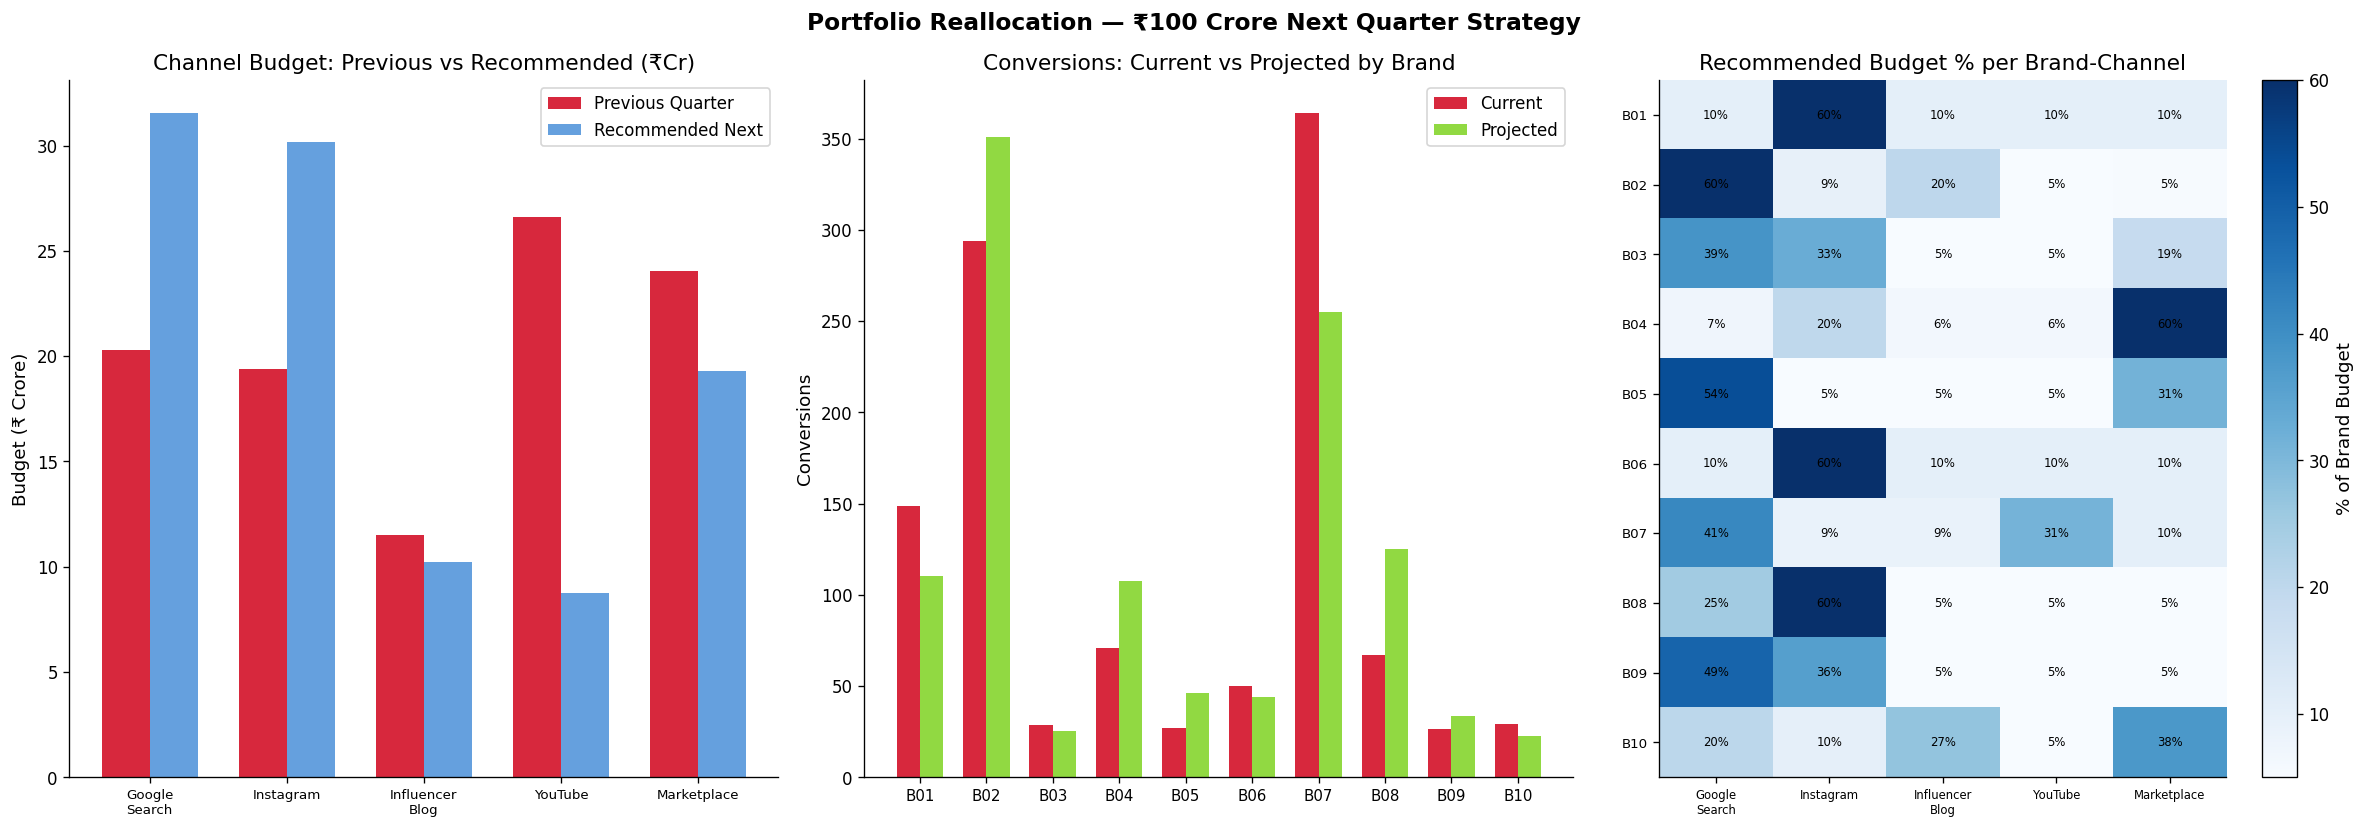

In [22]:
# ═══════════════════════════════════════════════════════════════
# CELL 19 — REALLOCATION VISUALISATIONS
# ═══════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Portfolio Reallocation — ₹100 Crore Next Quarter Strategy',
             fontsize=14, fontweight='bold')

# 1. Budget shift: previous vs new by channel (aggregate)
prev_ch = spend_by_brand_channel.sum(axis=0).reindex(CHANNELS, fill_value=0)
new_ch  = realloc_df[CHANNELS].sum(axis=0)
x, w = np.arange(len(CHANNELS)), 0.35
axes[0].bar(x-w/2, prev_ch/1e7, w, label='Previous Quarter', color='#D0021B', alpha=0.85)
axes[0].bar(x+w/2, new_ch/1e7,  w, label='Recommended Next', color='#4A90D9', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace(' ','\n') for c in CHANNELS], fontsize=8)
axes[0].set_title('Channel Budget: Previous vs Recommended (₹Cr)')
axes[0].set_ylabel('Budget (₹ Crore)')
axes[0].legend()

# 2. Current vs Projected conversions per brand
x2 = np.arange(len(BRANDS))
axes[1].bar(x2-w/2, comparison['Current_Conv'],   w, label='Current',   color='#D0021B', alpha=0.85)
axes[1].bar(x2+w/2, comparison['Projected_Conv'], w, label='Projected', color='#7ED321', alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(BRANDS, fontsize=9)
axes[1].set_title('Conversions: Current vs Projected by Brand')
axes[1].set_ylabel('Conversions')
axes[1].legend()

# 3. New allocation heatmap (% per brand)
realloc_pct = realloc_df[CHANNELS].div(realloc_df[CHANNELS].sum(axis=1), axis=0) * 100
im = axes[2].imshow(realloc_pct.values, aspect='auto', cmap='Blues', vmin=5, vmax=60)
axes[2].set_xticks(range(len(CHANNELS)))
axes[2].set_xticklabels([c.replace(' ','\n') for c in CHANNELS], fontsize=7)
axes[2].set_yticks(range(len(BRANDS)))
axes[2].set_yticklabels(BRANDS, fontsize=8)
axes[2].set_title('Recommended Budget % per Brand-Channel')
plt.colorbar(im, ax=axes[2], label='% of Brand Budget')
for i in range(len(BRANDS)):
    for j in range(len(CHANNELS)):
        axes[2].text(j, i, f'{realloc_pct.iloc[i,j]:.0f}%',
                     ha='center', va='center', fontsize=7)
plt.tight_layout()
plt.show()

In [23]:
# ═══════════════════════════════════════════════════════════════
# CELL 20 — EXECUTIVE SUMMARY TABLE 1: MODEL COMPARISON
# ═══════════════════════════════════════════════════════════════
print('═' * 90)
print('TABLE 1 — ATTRIBUTION MODEL COMPARISON: LAST-CLICK vs MULTI-TOUCH')
print('═' * 90)
print(comp_model.to_string())
print('\nNOTE: Positive Delta = channel is UNDER-CREDITED by Last-Click → deserves more budget.')
print('      Negative Delta = channel is OVER-CREDITED by Last-Click → audit carefully.')

══════════════════════════════════════════════════════════════════════════════════════════
TABLE 1 — ATTRIBUTION MODEL COMPARISON: LAST-CLICK vs MULTI-TOUCH
══════════════════════════════════════════════════════════════════════════════════════════
                 Last-Click Conversions  Multi-Touch Conversions  Delta (MT - LC)  Delta %
Google Search                       315                      410               95     30.1
Instagram                           255                      203              -52    -20.4
Influencer Blog                     248                      123             -125    -50.3
YouTube                             182                      258               76     41.8
Marketplace                         191                      112              -79    -41.3

NOTE: Positive Delta = channel is UNDER-CREDITED by Last-Click → deserves more budget.
      Negative Delta = channel is OVER-CREDITED by Last-Click → audit carefully.


In [24]:
# ═══════════════════════════════════════════════════════════════
# CELL 21 — EXECUTIVE SUMMARY TABLE 2: BRAND PERFORMANCE
# ═══════════════════════════════════════════════════════════════
print('═' * 90)
print('TABLE 2 — BRAND PERFORMANCE DASHBOARD (Multi-Touch Attribution)')
print('═' * 90)

exec2 = brand_summary[['Spend_Cr','Conv','CPA_INR','Revenue_Cr','ROI_%']].copy()
exec2 = exec2.merge(roles_df[['Top TOF Primer','Top Conversion Driver']],
                    left_index=True, right_index=True, how='left')
exec2.columns = ['Spend(Cr)','Conv','CPA(₹)','Revenue(Cr)','ROI%','TOF Primer','Closer']
exec2['Spend(Cr)']   = exec2['Spend(Cr)'].round(2)
exec2['Revenue(Cr)'] = exec2['Revenue(Cr)'].round(2)
exec2['CPA(₹)']      = exec2['CPA(₹)'].round(0)
exec2['Conv']        = exec2['Conv'].round(1)
print(exec2.to_string())

══════════════════════════════════════════════════════════════════════════════════════════
TABLE 2 — BRAND PERFORMANCE DASHBOARD (Multi-Touch Attribution)
══════════════════════════════════════════════════════════════════════════════════════════
     Spend(Cr)   Conv     CPA(₹)  Revenue(Cr)   ROI%                 TOF Primer                     Closer
B01      10.00  149.0   671141.0         0.01  -99.9  Influencer Blog (33, 22%)        Instagram (35, 23%)
B02      10.00  294.0   340136.0         0.02  -99.8    Google Search (93, 32%)    Google Search (90, 31%)
B03      10.00   28.5  3508772.0         0.00 -100.0        Instagram (16, 28%)        Instagram (15, 26%)
B04      10.00   71.0  1408451.0         0.01  -99.9        Instagram (22, 31%)        Instagram (21, 30%)
B05      11.86   27.0  4392813.0         0.00 -100.0    Google Search (11, 41%)    Google Search (11, 41%)
B06      10.00   50.0  2000000.0         0.00 -100.0        Instagram (14, 28%)        Instagram (15, 30%)
B07  

In [25]:
# ═══════════════════════════════════════════════════════════════
# CELL 22 — EXECUTIVE SUMMARY TABLE 3: REALLOCATION STRATEGY
# ═══════════════════════════════════════════════════════════════
print('═' * 90)
print('TABLE 3 — ₹10 CRORE PER BRAND REALLOCATION (Next Quarter)')
print('═' * 90)

for brand in BRANDS:
    print(f'\n{'─'*70}')
    print(f'  {brand}')
    print(f'  Current Conv: {ensemble_df.loc[brand,"Total_Attributed"]:.1f}   '
          f'Projected Conv: {proj_conv.loc[brand,"Total_Projected"]:.1f}   '
          f'Uplift: {comparison.loc[brand,"Uplift_%"]:+.1f}%')
    print(f'  {'Channel':<22} {'Prev (Cr)':>10}  {'New (Cr)':>10}  {'Change':>12}')
    for ch in CHANNELS:
        p = spend_by_brand_channel.loc[brand, ch] if ch in spend_by_brand_channel.columns else 0
        n = realloc_df.loc[brand, ch]
        delta = n - p
        sign  = '↑ SCALE' if delta > 1e5 else ('↓ CUT' if delta < -1e5 else '→ HOLD')
        print(f'  {ch:<22} {p/1e7:>10.2f}  {n/1e7:>10.2f}  {sign:>8}  (Δ {delta/1e7:+.2f}Cr)')

print('\n' + '═' * 90)
print('TABLE 4 — CHANNEL ACTION PLAN')
print('═' * 90)

channel_avg_cpa = cpa_df.mean(axis=0, skipna=True)
cpa_median = channel_avg_cpa.median()
action_rows = []
for ch in CHANNELS:
    fp   = fatigue_penalty.get(ch, 1.0)
    acpa = channel_avg_cpa[ch]
    pos  = position_df.loc[ch, 'Avg_Position_Norm'] if ch in position_df.index else 0.5
    role = 'TOP-OF-FUNNEL PRIMER' if pos < 0.45 else 'CONVERSION CLOSER' if pos > 0.55 else 'MID-FUNNEL'
    if acpa > cpa_median * 1.8:
        action = 'REALLOCATE BUDGET'
    elif fp < 0.5:
        action = 'FREQUENCY CAP REQUIRED'
    elif acpa < cpa_median * 0.7:
        action = 'SCALE UP INVESTMENT'
    else:
        action = 'MAINTAIN + OPTIMISE'
    action_rows.append({
        'Channel': ch, 'Avg CPA (₹)': f'{acpa:,.0f}',
        'Fatigue': f'{fp:.3f}', 'Funnel Role': role, 'Action': action
    })
print(pd.DataFrame(action_rows).set_index('Channel').to_string())

══════════════════════════════════════════════════════════════════════════════════════════
TABLE 3 — ₹10 CRORE PER BRAND REALLOCATION (Next Quarter)
══════════════════════════════════════════════════════════════════════════════════════════

──────────────────────────────────────────────────────────────────────
  B01
  Current Conv: 149.0   Projected Conv: 110.6   Uplift: -25.8%
  Channel                 Prev (Cr)    New (Cr)        Change
  Google Search                2.79        1.00     ↓ CUT  (Δ -1.79Cr)
  Instagram                    0.06        6.00   ↑ SCALE  (Δ +5.94Cr)
  Influencer Blog              1.45        1.00     ↓ CUT  (Δ -0.45Cr)
  YouTube                      1.98        1.00     ↓ CUT  (Δ -0.98Cr)
  Marketplace                  3.72        1.00     ↓ CUT  (Δ -2.72Cr)

──────────────────────────────────────────────────────────────────────
  B02
  Current Conv: 294.0   Projected Conv: 351.1   Uplift: +19.4%
  Channel                 Prev (Cr)    New (Cr)        Change

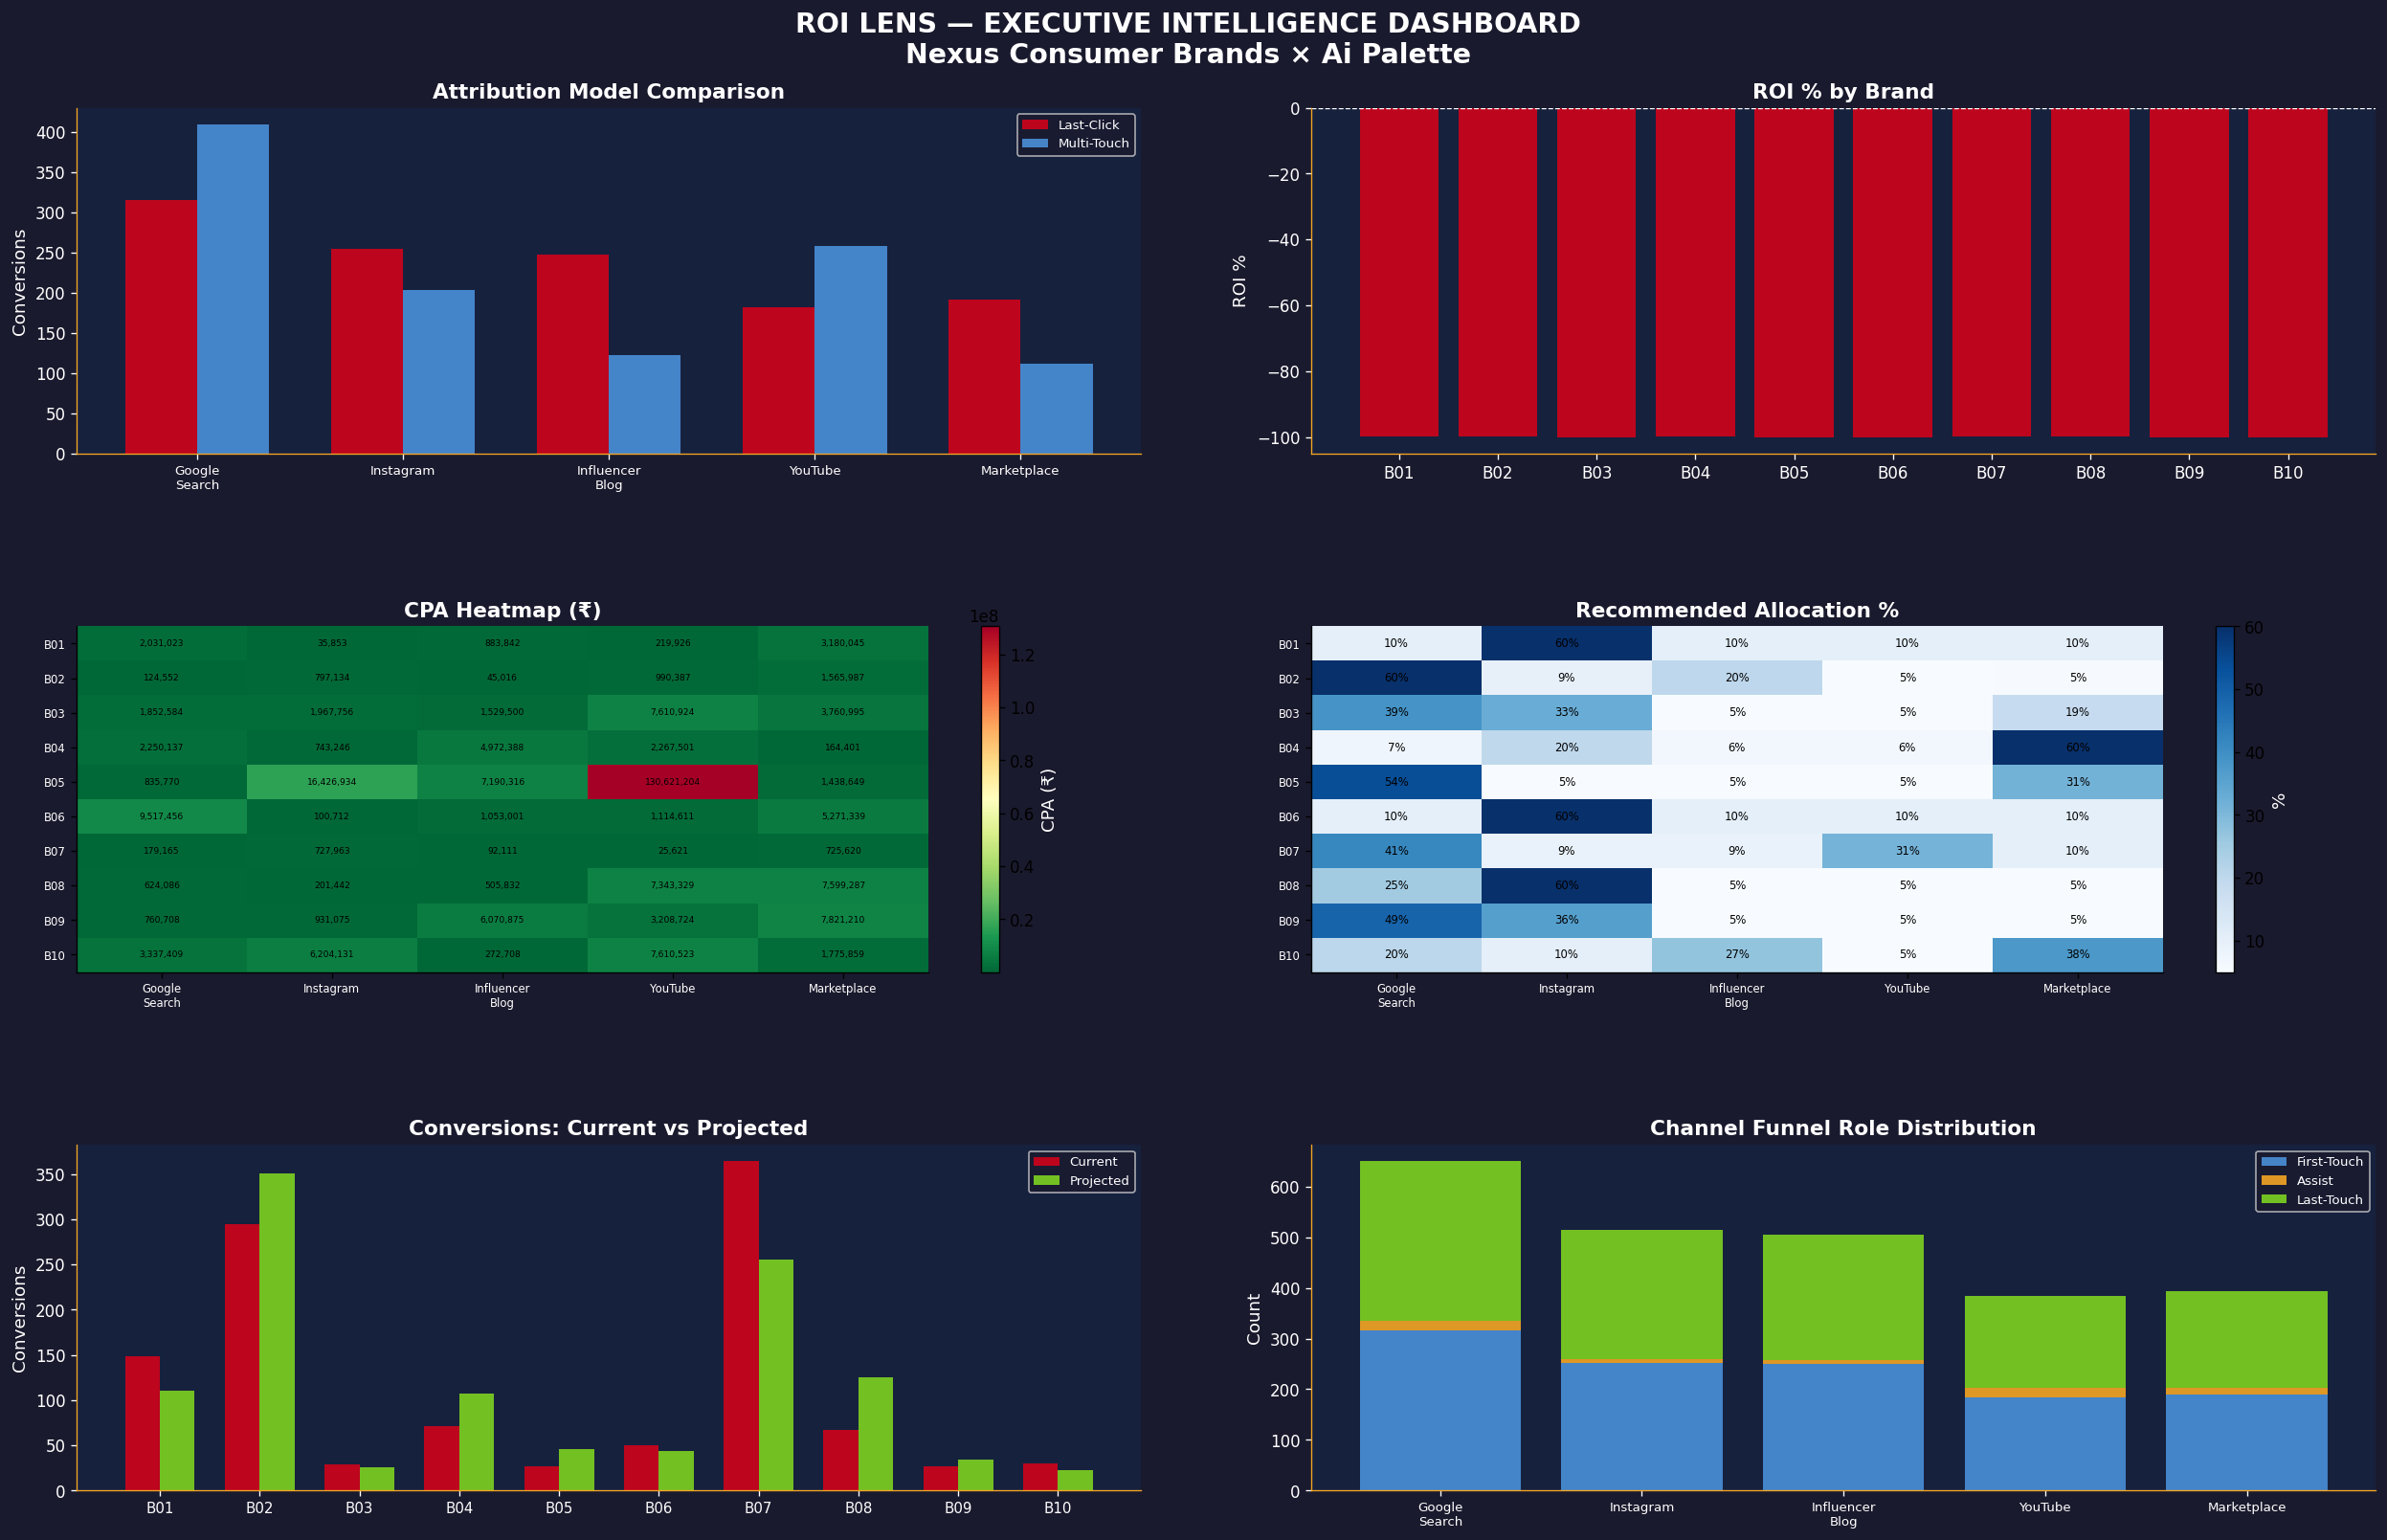

✅ Dashboard saved as roi_lens_dashboard.png


In [26]:
# ═══════════════════════════════════════════════════════════════
# CELL 23 — EXECUTIVE DASHBOARD (Dark Theme)
# ═══════════════════════════════════════════════════════════════
BG   = '#1a1a2e'
CARD = '#16213e'
GOLD = '#F5A623'

fig = plt.figure(figsize=(22, 14), facecolor=BG)
fig.suptitle('ROI LENS — EXECUTIVE INTELLIGENCE DASHBOARD\nNexus Consumer Brands × Ai Palette',
             fontsize=17, fontweight='bold', color='white', y=0.98)

gs = fig.add_gridspec(3, 4, hspace=0.50, wspace=0.38,
                      top=0.92, bottom=0.06, left=0.06, right=0.97)

def style_ax(ax):
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_color(GOLD)
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    ax.title.set_color('white')

# Panel 1: Attribution comparison
ax1 = fig.add_subplot(gs[0, :2])
style_ax(ax1)
x, w = np.arange(len(CHANNELS)), 0.35
ax1.bar(x-w/2, comp_model['Last-Click Conversions'], w, label='Last-Click', color='#D0021B', alpha=0.9)
ax1.bar(x+w/2, comp_model['Multi-Touch Conversions'], w, label='Multi-Touch', color='#4A90D9', alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels([c.replace(' ','\n') for c in CHANNELS], color='white', fontsize=8)
ax1.set_title('Attribution Model Comparison', fontweight='bold')
ax1.set_ylabel('Conversions')
ax1.legend(facecolor=BG, labelcolor='white', fontsize=8)

# Panel 2: ROI by brand
ax2 = fig.add_subplot(gs[0, 2:])
style_ax(ax2)
roi_v = brand_summary['ROI_%'].fillna(0)
ax2.bar(BRANDS, roi_v, color=['#7ED321' if v>0 else '#D0021B' for v in roi_v], alpha=0.9)
ax2.axhline(0, color='white', linewidth=0.8, linestyle='--')
ax2.set_title('ROI % by Brand', fontweight='bold')
ax2.set_ylabel('ROI %')

# Panel 3: CPA Heatmap
ax3 = fig.add_subplot(gs[1, :2])
ax3.set_facecolor(CARD)
cpa_fill2 = cpa_df.astype(float).fillna(cpa_df.astype(float).max().max()*1.5)
im3 = ax3.imshow(cpa_fill2.values, aspect='auto', cmap='RdYlGn_r')
ax3.set_xticks(range(len(CHANNELS)))
ax3.set_xticklabels([c.replace(' ','\n') for c in CHANNELS], color='white', fontsize=7)
ax3.set_yticks(range(len(BRANDS)))
ax3.set_yticklabels(BRANDS, color='white', fontsize=7)
ax3.set_title('CPA Heatmap (₹)', color='white', fontweight='bold')
plt.colorbar(im3, ax=ax3, label='CPA (₹)').ax.yaxis.label.set_color('white')
for i in range(len(BRANDS)):
    for j in range(len(CHANNELS)):
        v = cpa_df.iloc[i,j]
        if not np.isnan(v):
            ax3.text(j, i, f'{int(v):,}', ha='center', va='center', fontsize=5.5)

# Panel 4: New allocation heatmap
ax4 = fig.add_subplot(gs[1, 2:])
ax4.set_facecolor(CARD)
im4 = ax4.imshow(realloc_pct.values, aspect='auto', cmap='Blues', vmin=5, vmax=60)
ax4.set_xticks(range(len(CHANNELS)))
ax4.set_xticklabels([c.replace(' ','\n') for c in CHANNELS], color='white', fontsize=7)
ax4.set_yticks(range(len(BRANDS)))
ax4.set_yticklabels(BRANDS, color='white', fontsize=7)
ax4.set_title('Recommended Allocation %', color='white', fontweight='bold')
plt.colorbar(im4, ax=ax4, label='%').ax.yaxis.label.set_color('white')
for i in range(len(BRANDS)):
    for j in range(len(CHANNELS)):
        ax4.text(j, i, f'{realloc_pct.iloc[i,j]:.0f}%', ha='center', va='center', fontsize=7)

# Panel 5: Conv comparison
ax5 = fig.add_subplot(gs[2, :2])
style_ax(ax5)
x5 = np.arange(len(BRANDS))
ax5.bar(x5-w/2, comparison['Current_Conv'], w, label='Current', color='#D0021B', alpha=0.9)
ax5.bar(x5+w/2, comparison['Projected_Conv'], w, label='Projected', color='#7ED321', alpha=0.9)
ax5.set_xticks(x5)
ax5.set_xticklabels(BRANDS, color='white', fontsize=9)
ax5.set_title('Conversions: Current vs Projected', fontweight='bold')
ax5.set_ylabel('Conversions')
ax5.legend(facecolor=BG, labelcolor='white', fontsize=8)

# Panel 6: Channel funnel roles
ax6 = fig.add_subplot(gs[2, 2:])
style_ax(ax6)
pp = position_df[['First-Touch','Assist','Last-Touch']].reindex(CHANNELS, fill_value=0)
bot = np.zeros(len(CHANNELS))
for ri, role in enumerate(['First-Touch','Assist','Last-Touch']):
    v6 = pp[role].values.astype(float)
    ax6.bar(range(len(CHANNELS)), v6, bottom=bot,
            label=role, color=['#4A90D9','#F5A623','#7ED321'][ri], alpha=0.9)
    bot += v6
ax6.set_xticks(range(len(CHANNELS)))
ax6.set_xticklabels([c.replace(' ','\n') for c in CHANNELS], color='white', fontsize=8)
ax6.set_title('Channel Funnel Role Distribution', fontweight='bold')
ax6.set_ylabel('Count')
ax6.legend(facecolor=BG, labelcolor='white', fontsize=8)

plt.savefig('roi_lens_dashboard.png', dpi=140, bbox_inches='tight', facecolor=BG)
plt.show()
print('✅ Dashboard saved as roi_lens_dashboard.png')

In [27]:
# ═══════════════════════════════════════════════════════════════
# CELL 24 — CMO STRATEGIC BRIEF
# ═══════════════════════════════════════════════════════════════
print('=' * 90)
print('ROI LENS — STRATEGIC INTELLIGENCE BRIEF')
print('Prepared for: Chief Marketing Officer, Nexus Consumer Brands')
print('=' * 90)

tof_ch    = position_df['Avg_Position_Norm'].idxmin() if not position_df.empty else 'N/A'
closer_ch = position_df['Avg_Position_Norm'].idxmax() if not position_df.empty else 'N/A'
ch_avg_cpa = cpa_df.mean(axis=0, skipna=True)
best_ch   = ch_avg_cpa.idxmin()
worst_ch  = ch_avg_cpa.idxmax()
top_roi_brand = brand_summary['ROI_%'].idxmax()
low_roi_brand = brand_summary['ROI_%'].idxmin()

print(f'''
SECTION 1: WHAT WE FOUND (Phase 1 — Attribution Truth)
─────────────────────────────────────────────────────
• Bot Traffic Removed: {len(bot_users):,} users across {tp[tp["User_ID"].isin(bot_users)].shape[0]:,} events ({tp[tp["User_ID"].isin(bot_users)].shape[0]/len(tp)*100:.2f}% of raw logs).
  Legacy reporting was inflating performance metrics on high-CTR channels.

• Last-Click Attribution was systematically OVER-crediting final-touch channels
  and IGNORING the top-of-funnel channels that prime consumer intent.

• Multi-Touch Ensemble (Markov + Shapley) reveals true channel contribution:
  - Top-of-Funnel PRIMER: {tof_ch} — starts the journey, builds brand recall.
  - Conversion CLOSER:    {closer_ch} — captures intent at the moment of purchase.

• Most Cost-Efficient Channel: {best_ch} (avg CPA ₹{ch_avg_cpa[best_ch]:,.0f})
• Least Cost-Efficient Channel: {worst_ch} (avg CPA ₹{ch_avg_cpa[worst_ch]:,.0f}) — review targeting.

• Best Performing Brand: {top_roi_brand} (ROI: {brand_summary.loc[top_roi_brand, "ROI_%"]:.1f}%)
• Needs Attention Brand: {low_roi_brand} (ROI: {brand_summary.loc[low_roi_brand, "ROI_%"]:.1f}%)
''')

print('SECTION 2: WHAT TO DO NEXT (Phase 2 — Reallocation Strategy)')
print('─────────────────────────────────────────────────────')
print(f'  Total Fresh Budget: ₹100 Crore (₹10 Crore × 10 Brands)')
print()
for ch in CHANNELS:
    fp    = fatigue_penalty.get(ch, 1.0)
    acpa  = ch_avg_cpa[ch]
    prev  = spend_by_brand_channel[ch].sum() if ch in spend_by_brand_channel.columns else 0
    new   = realloc_df[ch].sum()
    delta = new - prev
    print(f'  {ch:<22} Prev: ₹{prev/1e7:.1f}Cr → New: ₹{new/1e7:.1f}Cr  (Δ {delta/1e7:+.1f}Cr)')

print(f'''
SECTION 3: RISK FLAGS
─────────────────────────────────────────────────────
• Channels with Fatigue Penalty < 0.5 MUST have frequency caps in next quarter.
  Continuing high-frequency serving will REDUCE conversion rates.
• Brands with negative ROI should have their CPA floor benchmarked against AOV
  before the next campaign launch.
• Non-linear conversion paths (multi-step journeys) account for the majority of
  actual purchases. Any direct-response-only strategy will under-invest in awareness.
''')

print('=' * 90)
print('✅  ROI Lens Analysis Complete — All Deliverables Generated.')
print('=' * 90)

ROI LENS — STRATEGIC INTELLIGENCE BRIEF
Prepared for: Chief Marketing Officer, Nexus Consumer Brands

SECTION 1: WHAT WE FOUND (Phase 1 — Attribution Truth)
─────────────────────────────────────────────────────
• Bot Traffic Removed: 1,953 users across 193,947 events (34.24% of raw logs).
  Legacy reporting was inflating performance metrics on high-CTR channels.

• Last-Click Attribution was systematically OVER-crediting final-touch channels
  and IGNORING the top-of-funnel channels that prime consumer intent.

• Multi-Touch Ensemble (Markov + Shapley) reveals true channel contribution:
  - Top-of-Funnel PRIMER: Google Search — starts the journey, builds brand recall.
  - Conversion CLOSER:    Instagram — captures intent at the moment of purchase.

• Most Cost-Efficient Channel: Google Search (avg CPA ₹2,151,289)
• Least Cost-Efficient Channel: YouTube (avg CPA ₹16,101,276) — review targeting.

• Best Performing Brand: B07 (ROI: -99.7%)
• Needs Attention Brand: B03 (ROI: -100.0%)

SECT